# 🔍 Identifying Missingness Mechanisms & Selecting an Imputation Strategy

## 📌 Introduction

Missing-value handling is often treated as a simple preprocessing step:

> **Find the missing values → replace them with mean, median, or mode → continue with model building.**

However, this approach can be misleading.

The more important questions are:

> **Why are the values missing?**  
> **Do different features become missing together?**  
> **Can the occurrence of missingness be explained using the information available in the dataset?**  
> **Will a particular imputation method distort the original feature distribution?**  
> **And most importantly, which imputation strategy actually works better for the downstream machine-learning model?**

This notebook explores these questions systematically for the **Swiggy Delivery Time Prediction** dataset.

The objective is not simply to remove `NaN` values, but to understand the **structure and possible mechanism of missingness**, evaluate suitable imputation strategies, and finally build a preprocessing pipeline that can be applied consistently to both the training and unseen test data.

---

## 🎯 Objectives of this Notebook

The major objectives of this analysis are:

- 🔎 Identify which features contain missing values.
- 📊 Measure the amount and percentage of missingness in each feature.
- 🧩 Study whether different features tend to become missing together.
- 🔗 Analyze pairwise missingness relationships using nullity correlations.
- 🧠 Investigate whether missingness can be predicted from the available information in the dataset.
- 🧪 Search for **MAR-like evidence** using missingness-prediction experiments.
- 📉 Study how simple imputation methods affect the original feature distributions.
- ⚖️ Compare simple and multivariate imputation approaches.
- 🚩 Investigate whether preserving missingness indicators provides useful predictive information.
- 🔄 Build preprocessing pipelines that correctly learn from the training data and transform unseen data.
- 📈 Compare the downstream predictive performance obtained after imputation.
- 🗑️ Compare imputation against **Complete Case Analysis (CCA)** as an additional baseline.
- 💾 Produce clean, fully imputed training and test datasets for the next stage of the machine-learning project.

---

## 🧠 Understanding the Missingness Mechanism

Before deciding how to fill a missing value, it is useful to understand the three classical missing-data mechanisms.

### 🟢 MCAR — Missing Completely At Random

Under **MCAR**, the probability that a value is missing is unrelated to:

- the observed variables, and
- the actual unobserved value itself.

In other words, the missingness occurs completely randomly.

---

### 🟡 MAR — Missing At Random

Under **MAR**, the probability of missingness can be associated with information that is already observed in the dataset.

This means that the missingness may be **systematic and partially explainable using available variables**.

---

### 🔴 MNAR — Missing Not At Random

Under **MNAR**, the probability that a value is missing depends on the unobserved value itself or on information that is unavailable to us.

This mechanism is considerably harder to establish using the observed dataset alone.

---

## ⚠️ An Important Statistical Point

A dataset usually does not provide enough information to **prove** that a particular feature is MCAR, MAR, or MNAR.

Therefore, this notebook does not blindly assign a missingness label based on a single graph or correlation value.

Instead, multiple sources of evidence are combined:

- 📊 Missing-value percentages
- 🧩 Nullity Matrix
- 🌳 Nullity Dendrogram
- 🔥 Nullity Heatmap
- 🔗 Pearson and Spearman correlations between missingness indicators
- 🤖 Missingness-prediction experiments
- 📉 Distribution analysis before and after imputation
- 🧠 Feature-generation and domain knowledge
- 📈 Downstream model performance

The goal is therefore to identify **missingness structure and MAR-like evidence**, rather than claiming that the true missing-data mechanism has been mathematically proven.

---

## 🧩 1. Exploring the Structure of Missingness

The analysis begins with the `missingno` library to visualize the overall architecture of missingness.

The following visualizations are explored:

### 📊 Nullity Bar Chart

Used to understand the amount of available and missing information in each feature.

### 🧱 Nullity Matrix

Used to visually inspect whether features tend to become missing together across observations.

### 🌳 Nullity Dendrogram

Used to identify groups of variables that exhibit similar missingness patterns.

### 🔥 Nullity Heatmap

Used to quantify pairwise relationships between feature-missingness indicators.

These visualizations help distinguish between:

> **isolated missingness**

and

> **structured / block-wise co-missingness**

For example, some rider-related and order-time-related variables in this dataset exhibit strong co-missingness patterns, while other variables show comparatively isolated missingness.

Importantly:

> **Strong co-missingness describes the structure of missingness, but does not by itself prove MCAR, MAR, or MNAR.**

---

## 🤖 2. Searching for MAR-like Evidence

The next question is:

> **Can we predict whether a value will be missing using information available in the dataset?**

For each feature containing missing values, its missingness can be represented as a binary target:

- `1` → value is missing
- `0` → value is observed

A classification-based experiment is then used to determine how predictable that missingness is from other available variables.

Performance is evaluated using **Macro-F1**, including performance on unseen data.

If missingness is strongly predictable from observed information, this provides evidence that the missingness is **systematic and MAR-like**.

However:

> **High missingness-prediction performance is evidence of MAR-like structure — it is not formal proof of MAR.**

Similarly, poor predictability does not automatically prove MCAR or MNAR.

---

## 🔎 3. Feature-Level Imputation Analysis

Instead of applying one universal imputation technique to every column, the missing features are investigated individually.

For numerical features such as:

- `rider_age`
- `rider_ratings`
- `order_pickup_time_mins`
- `multiple_deliveries`
- `distance_km`
- `order_placed_hr`

the notebook examines:

- feature type
- valid value domain
- percentage of missingness
- missingness structure
- MAR-like evidence
- original feature distribution
- distribution after mean imputation
- distribution after median imputation
- suitability of multivariate imputation

This is particularly important for discrete features.

For example, replacing every missing value with a single mean or median value may create an **artificial spike in the distribution** even when the imputed value itself appears reasonable.

---

## 🔄 4. Multivariate Numerical Imputation

When simple constant-value imputation may lose information or distort the feature distribution, multivariate approaches are explored.

The notebook evaluates methods such as:

### 🔁 Iterative Imputer

`IterativeImputer` estimates a missing feature using relationships with other numerical variables.

Rather than treating each column independently, it attempts to exploit multivariate relationships available in the dataset.

### 👥 K-Nearest Neighbors Imputer

`KNNImputer` estimates missing values using observations that are similar across the available numerical features.

A distance-weighted KNN strategy is explored so that closer observations can contribute more strongly to the estimated value.

---

## 🚩 5. Missingness Indicators

Imputation replaces a missing value, but after replacement the model normally cannot distinguish between:

> an originally observed value

and

> a value created through imputation.

Missingness indicators can preserve this information.

For example:

`rider_age = 30`

and

`rider_age = 30, but originally missing`

may carry different information.

Therefore, the notebook also investigates whether explicitly retaining missingness information improves downstream predictive performance.

The usefulness of a missingness indicator is evaluated empirically rather than assumed in advance.

---

## 🏷️ 6. Categorical and Boolean Missing Values

Categorical and Boolean variables are handled separately from numerical variables.

For features such as:

- `order_day_of_week`
- `weather`
- `traffic`
- `is_festival`
- `is_friday_night`
- `is_weekend`

simple categorical imputation strategies such as:

`SimpleImputer(strategy='most_frequent')`

are explored.

The notebook also ensures that categorical variables are encoded appropriately before model building.

Nominal variables are handled using **One-Hot Encoding**, while variables with meaningful order, such as traffic intensity, are handled using **Ordinal Encoding**.

---

## 🌍 7. Special Treatment of Geospatial Information

`distance_km` is not an independently collected feature.

It was derived from:

- restaurant latitude
- restaurant longitude
- delivery latitude
- delivery longitude

using the **Haversine distance formula**.

Therefore, missing coordinate information can directly result in a missing `distance_km` value.

The notebook considers this feature-generation process while interpreting its missingness.

Raw latitude and longitude coordinates are not retained in the final feature set because blindly imputing geographical coordinates as ordinary numerical values may generate mathematically possible but geographically unrealistic locations.

Instead, the derived Haversine distance is retained as a more compact representation of spatial separation.

---

## ⏰ 8. Preserving Cyclical Time Features

Time-of-day information is represented not only through `order_placed_hr`, but also through cyclical transformations:

`sin_hr`

and

`cos_hr`.

After imputation of the underlying hour information, these cyclical features are recalculated so that their mathematical relationship remains consistent:

$$
\sin^2(\theta) + \cos^2(\theta) = 1
$$

This prevents independently imputed sine and cosine values from violating their original cyclical structure.

---

## 🧪 9. Comparing Different Imputation Pipelines

Rather than selecting an imputation technique purely from theoretical assumptions, multiple preprocessing strategies are constructed and compared.

The experiments include combinations involving:

- Iterative Imputation
- Iterative Imputation with missing indicators
- KNN Imputation
- Most-frequent categorical imputation
- Appropriate categorical encoding
- Random Forest regression as a downstream predictive model

This allows the imputation strategy to be evaluated based on an important practical question:

> **After replacing the missing values, how well does the downstream machine-learning model perform?**

---

## 🏗️ 10. Train → Transform Workflow

A critical objective of the notebook is to preserve a proper machine-learning workflow.

The preprocessing logic follows the principle:

**Fit on training data → transform training data → transform unseen test data**

This ensures that information from the test set is not used to learn preprocessing parameters.

`Pipeline` and `ColumnTransformer` are used wherever appropriate to organize the preprocessing workflow.

---

## 📉 11. Distribution Validation After Imputation

Removing all `NaN` values is not sufficient.

After the selected imputation process, the distributions of the transformed features are checked again to determine whether imputation introduced major artificial changes.

This provides another layer of validation beyond simply checking:

`df.isnull().sum() == 0`

---

## ⚔️ 12. Imputation vs Complete Case Analysis

The notebook also compares the imputation-based dataset against **Complete Case Analysis (CCA)**.

CCA removes observations containing missing values, while imputation attempts to preserve those observations by estimating the missing information.

Baseline regression models are used to compare the predictive behaviour of the resulting datasets.

This comparison helps investigate whether preserving incomplete observations through imputation provides a useful alternative to simply discarding them.

---

## 📦 Final Outcome

By the end of this notebook, the workflow moves from:

**Raw data with missing values**

⬇️

**Missingness exploration**

⬇️

**Nullity structure analysis**

⬇️

**MAR-like evidence investigation**

⬇️

**Feature-specific distribution analysis**

⬇️

**Candidate imputation strategies**

⬇️

**Pipeline-based comparison**

⬇️

**Final imputation workflow**

⬇️

**Distribution & consistency validation**

⬇️

**Baseline model comparison**

⬇️

**Clean imputed training and test datasets**

These transformed datasets are then exported and can be used in the next stage of the **Swiggy Delivery Time Prediction** project.

---

## 💡 Key Philosophy of this Notebook

The central idea behind this notebook is:

> **Imputation should not be treated as a mechanical process of filling `NaN` values.**

A better approach is to first understand:

**Why is the value missing?**

then investigate:

**What information can help estimate the missing value?**

and finally validate:

**Does the chosen strategy preserve useful information and improve the downstream modeling pipeline?**

The final imputation decision is therefore based on a combination of:

**statistical evidence + missingness structure + feature characteristics + domain reasoning + empirical model performance.** 🚀

# Necessary Imports

In [5]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
sns.set_theme('paper')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Import DataFrame

In [7]:
data_types_trf = {'vehicle_condition':'object',
                  'is_lunch_rush':'boolean',
                  'is_dinner_rush':'boolean',
                  'is_friday_night':'boolean',
                  'is_weekend':'boolean',
                  'is_month_start':'boolean',
                  'is_month_end': 'boolean',
                  'is_festival':'boolean'}

In [8]:
train_df = pd.read_csv('/content/4. swiggy_train_data_not_imputed.csv', dtype = data_types_trf)
test_df = pd.read_csv('/content/5. swiggy_test_data_not_imputed.csv', dtype = data_types_trf)

In [9]:
train_df.head()

,rider_age,rider_ratings,multiple_deliveries,vehicle_type,vehicle_condition,city_name,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,distance_km,order_type,order_placed_datetime,order_picked_datetime,order_pickup_time_mins,order_placed_hr,sin_hr,cos_hr,order_time_of_day,is_lunch_rush,is_dinner_rush,order_day,order_day_of_week,is_friday_night,is_weekend,order_month,is_month_start,is_month_end,is_festival,weather,traffic,time_taken
0,32.0,4.6,1.0,Scooter,1,Chennai,12.972793,80.249982,13.012793,80.289982,6.210138,Snack,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,13.0,-0.2588,-0.9659,Afternoon,True,False,26.0,Saturday,False,True,3.0,False,False,False,Cloudy,High,30
1,22.0,4.8,1.0,Motor-Cycle,0,Hyderabad,17.431668,78.408321,17.461668,78.438321,4.610365,Buffet,2022-03-11 21:20:00,2022-03-11 21:30:00,10.0,21.0,-0.7071,0.7071,Night,False,True,11.0,Friday,True,False,3.0,False,False,False,Cloudy,Jam,26
2,33.0,4.7,1.0,Scooter,1,Ranchi,23.369746,85.339820,23.479746,85.449820,16.600361,Meal,2022-03-04 19:15:00,2022-03-04 19:30:00,15.0,19.0,-0.9659,0.2588,Evening,False,False,4.0,Friday,True,False,3.0,False,False,False,Fog,Jam,40
3,35.0,4.6,1.0,Motor-Cycle,2,Mysore,12.352058,76.606650,12.482058,76.736650,20.205253,Meal,2022-03-14 17:25:00,2022-03-14 17:30:00,5.0,17.0,-0.9659,-0.2588,Evening,False,False,14.0,Monday,False,False,3.0,False,False,False,Cloudy,Medium,32
4,22.0,4.8,1.0,Motor-Cycle,0,Hyderabad,17.433809,78.386744,17.563809,78.516744,19.975520,Buffet,2022-03-20 20:55:00,2022-03-20 21:05:00,10.0,20.0,-0.8660,0.5000,Evening,False,True,20.0,Sunday,False,True,3.0,False,False,False,Stormy,Jam,34


In [10]:
test_df.head()

,rider_age,rider_ratings,multiple_deliveries,vehicle_type,vehicle_condition,city_name,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,distance_km,order_type,order_placed_datetime,order_picked_datetime,order_pickup_time_mins,order_placed_hr,sin_hr,cos_hr,order_time_of_day,is_lunch_rush,is_dinner_rush,order_day,order_day_of_week,is_friday_night,is_weekend,order_month,is_month_start,is_month_end,is_festival,weather,traffic,time_taken
0,37.0,4.9,0.0,Motor-Cycle,2,Indore,22.745049,75.892471,22.765049,75.912471,3.025149,Snack,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,11.0,0.2588,-0.9659,Morning,False,False,19.0,Saturday,False,True,3.0,False,False,False,Sunny,High,24
1,29.0,4.7,0.0,Motor-Cycle,1,Bangalore,12.933284,77.615428,12.943284,77.625428,1.552700,Snack,2022-03-21 11:20:00,2022-03-21 11:35:00,15.0,11.0,0.2588,-0.9659,Morning,False,False,21.0,Monday,False,False,3.0,False,False,False,Sandstorms,High,16
2,34.0,4.5,1.0,Scooter,2,Bangalore,12.913041,77.683237,13.043041,77.813237,20.183530,Snack,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,19.0,-0.9659,0.2588,Evening,False,False,25.0,Friday,True,False,3.0,False,False,False,Stormy,Jam,33
3,38.0,4.7,1.0,Motor-Cycle,0,Coimbatore,11.003669,76.976494,11.053669,77.026494,7.790401,Buffet,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,18.0,-1.0000,-0.0000,Evening,False,False,5.0,Tuesday,False,False,4.0,False,False,False,Sunny,Medium,21
4,20.0,4.8,1.0,Motor-Cycle,0,Hyderabad,17.410371,78.437225,17.470371,78.497225,9.220882,Buffet,2022-04-01 21:25:00,2022-04-01 21:40:00,15.0,21.0,-0.7071,0.7071,Night,False,True,1.0,Friday,True,False,4.0,True,False,False,Sandstorms,Jam,35


In [11]:
train_df.shape

(36401, 32)

In [12]:
test_df.shape

(9100, 32)

# Analysing Missing Values

In [13]:
def get_missing_info(df:pd.DataFrame):

   d1 = df.dtypes.reset_index() # datatypes
   d2 = df.isnull().sum().reset_index() # missing value count

   missing_info = d1.merge(d2, how = 'inner', on = 'index')
   missing_info.columns = ['feature', 'data_type', 'missing_count']
   missing_info['missing_%'] = round((missing_info['missing_count']/len(df))*100,2)

   return missing_info

In [14]:
t1 = get_missing_info(train_df)
t2 = get_missing_info(test_df)

pd.concat([t1,t2], axis = 1)

,feature,data_type,missing_count,missing_%,feature,data_type,missing_count,missing_%
0,rider_age,float64,1502,4.13,rider_age,float64,351,3.86
1,rider_ratings,float64,1541,4.23,rider_ratings,float64,366,4.02
2,multiple_deliveries,float64,808,2.22,multiple_deliveries,float64,185,2.03
3,vehicle_type,object,0,0.00,vehicle_type,object,0,0.00
4,vehicle_condition,object,0,0.00,vehicle_condition,object,0,0.00
5,city_name,object,0,0.00,city_name,object,0,0.00
6,restaurant_latitude,float64,2854,7.84,restaurant_latitude,float64,776,8.53
7,restaurant_longitude,float64,2854,7.84,restaurant_longitude,float64,776,8.53
8,delivery_latitude,float64,2854,7.84,delivery_latitude,float64,776,8.53
9,delivery_longitude,float64,2854,7.84,delivery_longitude,float64,776,8.53


In [15]:
X = train_df[['rider_age', 'rider_ratings', 'order_placed_datetime', 'order_pickup_time_mins',
              'restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'distance_km',
              'order_placed_hr', 'sin_hr', 'cos_hr', 'order_day', 'order_day_of_week', 'is_friday_night', 'is_weekend',
              'is_festival', 'weather', 'traffic', 'multiple_deliveries', 'order_picked_datetime', 'vehicle_type', 'vehicle_condition', 'city_name',
              'order_type', 'is_lunch_rush', 'is_dinner_rush', 'order_time_of_day', 'order_month', 'is_month_start', 'is_month_end']]

In [16]:
rows, cols = X.shape
missing_cells = X.isnull().sum().sum()
missing_atleast_rows = X.isnull().any(axis = 1).sum()
missing_all_rows = X.isnull().all(axis = 1).sum()
rows_duplicated = X.duplicated().sum()

print(f'There are {rows} rows and {cols} features in the dataset')
print(f'There are {missing_cells} missing cells out of {train_df.size} total cells, which signifies that {round((missing_cells/train_df.size)*100,2)}% of the data is missing')
print(f'There are {missing_atleast_rows} rows containing at least one missing value out of {rows}, which accounts for {round((missing_atleast_rows/rows)*100,2)}% of total rows')
print(f'There are {missing_all_rows} rows containing all missing values, which accounts for {round((missing_all_rows/rows)*100,2)}% of total rows')
print(f'There are {rows_duplicated} duplicated rows')

There are 36401 rows and 31 features in the dataset
There are 22090 missing cells out of 1164832 total cells, which signifies that 1.9% of the data is missing
There are 5127 rows containing at least one missing value out of 36401, which accounts for 14.08% of total rows
There are 0 rows containing all missing values, which accounts for 0.0% of total rows
There are 0 duplicated rows


# Missing no library

In [17]:
import missingno as msno

## a. Nullity Bar chart

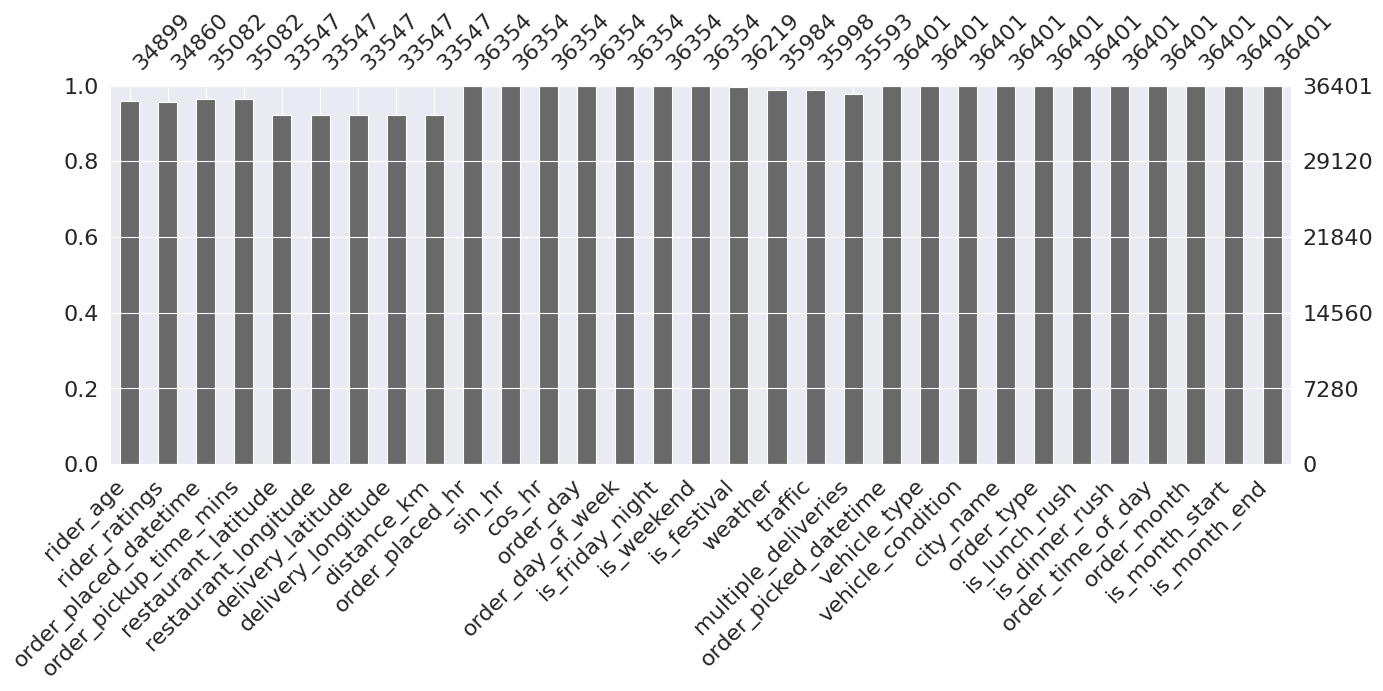

In [18]:
fig,ax = plt.subplots(nrows = 1, ncols = 1, figsize = (14,7))
msno.bar(X, ax = ax)
plt.tight_layout()
plt.show()

## b. Nullity-Matrix Chart

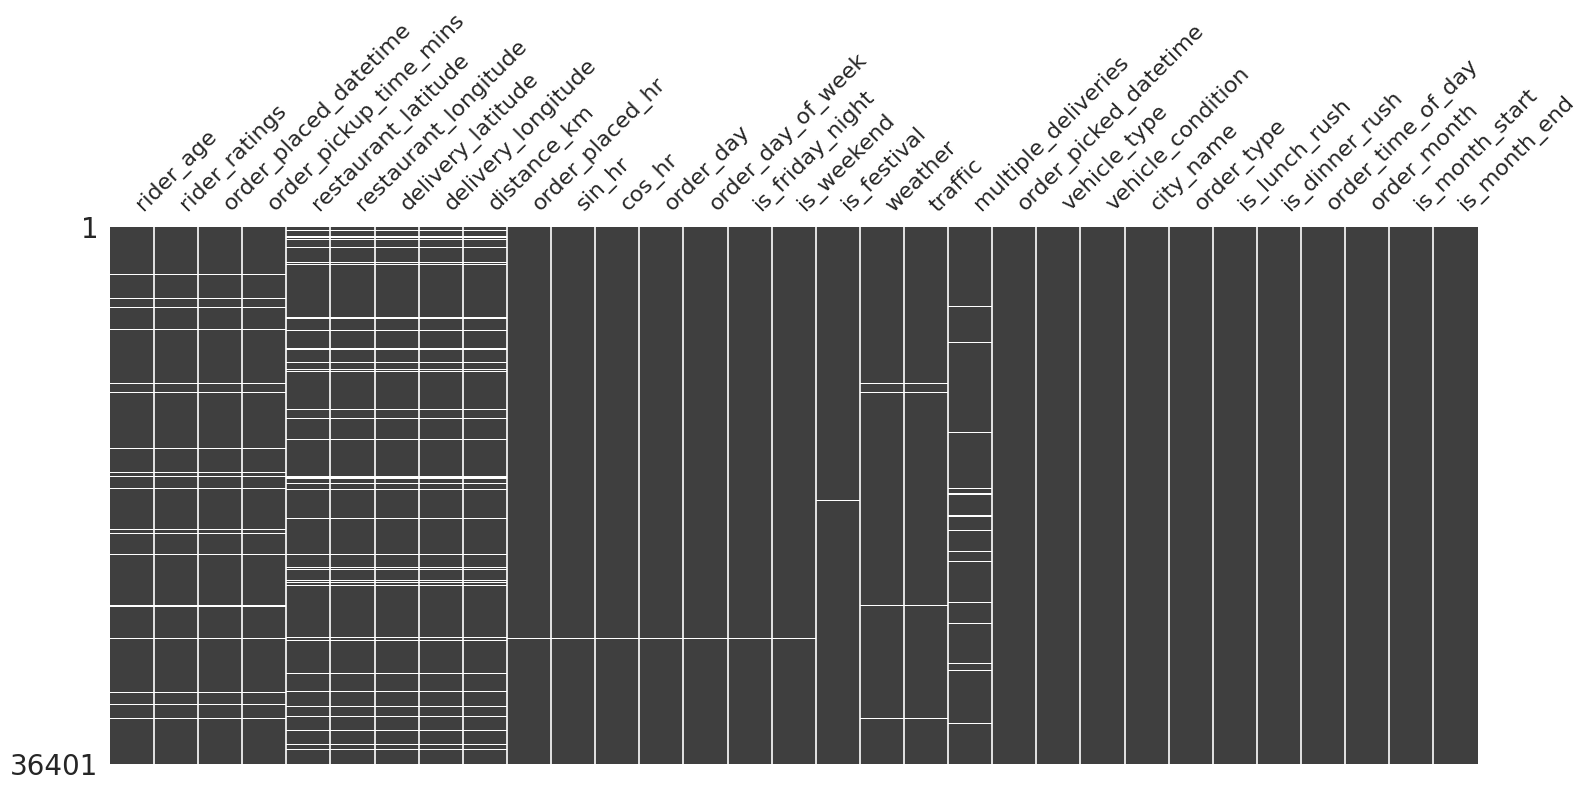

In [19]:
fig,ax = plt.subplots(nrows = 1, ncols = 1, figsize = (16,8))
msno.matrix(X, ax = ax)
plt.tight_layout()
plt.show()

## c. Nullity-Dendrogram

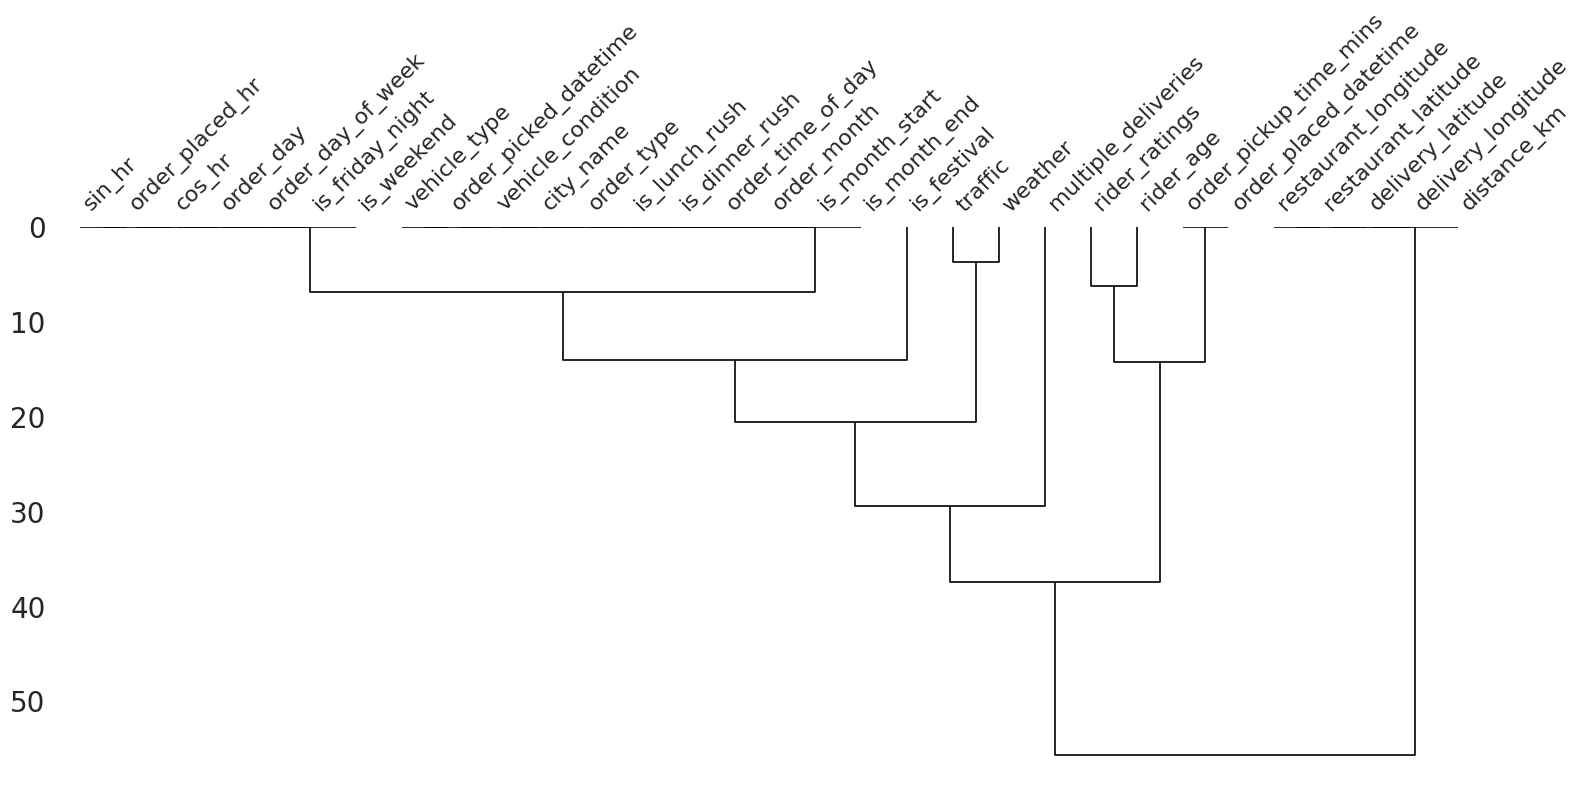

In [20]:
fig,ax = plt.subplots(nrows = 1, ncols = 1, figsize = (16,8))
msno.dendrogram(X, ax = ax)
plt.tight_layout()
plt.show()

## d. Nullity-Heatmap

### Missingness Correlation — Complete Guide

---
## 🔴 Correlation = -1

### Meaning

- The two variables have perfectly opposite missingness patterns.
- When the value in one column is present, the value in the other column is always missing.
- When one column is missing, the other one is always present.
- Their missingness indicators are perfectly negatively correlated.
- The two missingness indicators are perfectly complementary.

### Example

| A     | B     |
|-------|-------|
| value | NaN   |
| NaN   | value |
| value | NaN   |
| NaN   | value |
| value | NaN   |
| NaN   | value |
| value | NaN   |
| NaN   | value |

- If A is observed → B is missing
- If A is missing → B is observed
- If B is observed → A is missing
- If B is missing → A is observed
- This produces **exactly -1**

## 🔴 Correlation Near -1
- Very strong inverse missing pattern.
- The two variables are almost always opposite in their missingness.
- A few exceptions may exist, but the overall pattern is strongly inverse.

---
## ⚪ Correlation = 0

### Meaning
- There is no marginal pairwise Pearson association between the two missingness indicators.
- Knowing whether Column A is missing does not provide useful pairwise information about whether Column B is missing.
- There is no pairwise co-missingness pattern.
- There is no pairwise complementary-missingness pattern.
- For two non-constant binary missingness indicators, exact Pearson correlation of 0 corresponds to marginal pairwise independence between those two indicators.
- However, this is only pairwise marginal independence.
- It does NOT mean that the missingness is independent of:
  - all other observed variables
  - combinations of variables
  - conditional relationships
  - the feature's own unobserved value

Therefore: Correlation = 0 => does Not impley MCAR

### Example
| A     | B     |
| ----- | ----- |
| value | value |
| value | value |
| NaN   | value |
| NaN   | value |
| NaN   | NaN   |
| NaN   | NaN   |
| value | NaN   |
| value | NaN   |
| value | value |
| value | value |

-  There is no consistent pairwise tendency for A and B to become missing together or in opposite directions.
- This produces **exactly 0**.

---
## ⚪ Correlation Near 0
- There is little or no meaningful pairwise association in the missingness indicators.
- There is no strong co-missingness pattern.
- There is no strong complementary-missingness pattern.
- Near-zero correlation should be interpreted as weak pairwise missingness association.

Correlation ≈ 0 indicates:
- Absence of strong pairwise co-missingness structure
- But it does NOT establish MCAR
- It does NOT prove full statistical independence
- Missingness relationships can still be conditional or involve other variables

Do not automatically say: This missingness is random

A safter statement is : There is little evidence of pairwise association between the missingness patterns of the two features.

---
## 📈 Correlation = +1 (Perfect Positive Correlation)

### Meaning
- The two variables have identical missing patterns.
- When value in Column A is missing, the other value in Column B is always missing.
- When value in Column A is present, the other value in Column B is always present.
- Their missingness indicators are perfectly positively correlated.
- The two features show perfect co-missingness.

### Example
| A     | B     |
| ----- | ----- |
| value | value |
| NaN   | NaN   |
| value | value |
| NaN   | NaN   |
| NaN   | NaN   |
| NaN   | NaN   |
| value | value |
| value | value |

- They are missing together 100% of the time.
- They are present together 100% of the time.
- The variables always appear or disappear together.
- This produces exactly +1

---
## 📈 Correlation Near +1
- There is very strong co-missing behavior.
- The variables almost always become missing together.
- They almost always become present together.
- Minor inconsistencies may exist.
- The closer the correlation is to +1, the stronger the co-missingness structure.

---
## 🧠 Important Conceptual Note
This Nullity correlation:
- ❌ Is **NOT** correlation between actual values.
- ✅ Is correlation between **missingness indicators** (1 = missing, 0 = present).
- **Therefore, it describes the structure of missing data — not the relationship between feature values.**

---
## **⚠️ Near-Perfect Correlations**
- `< 1` means the correlation is very close to +1, but not exactly +1
- `>-1` means the correlation is very close to -1, but not exactly -1

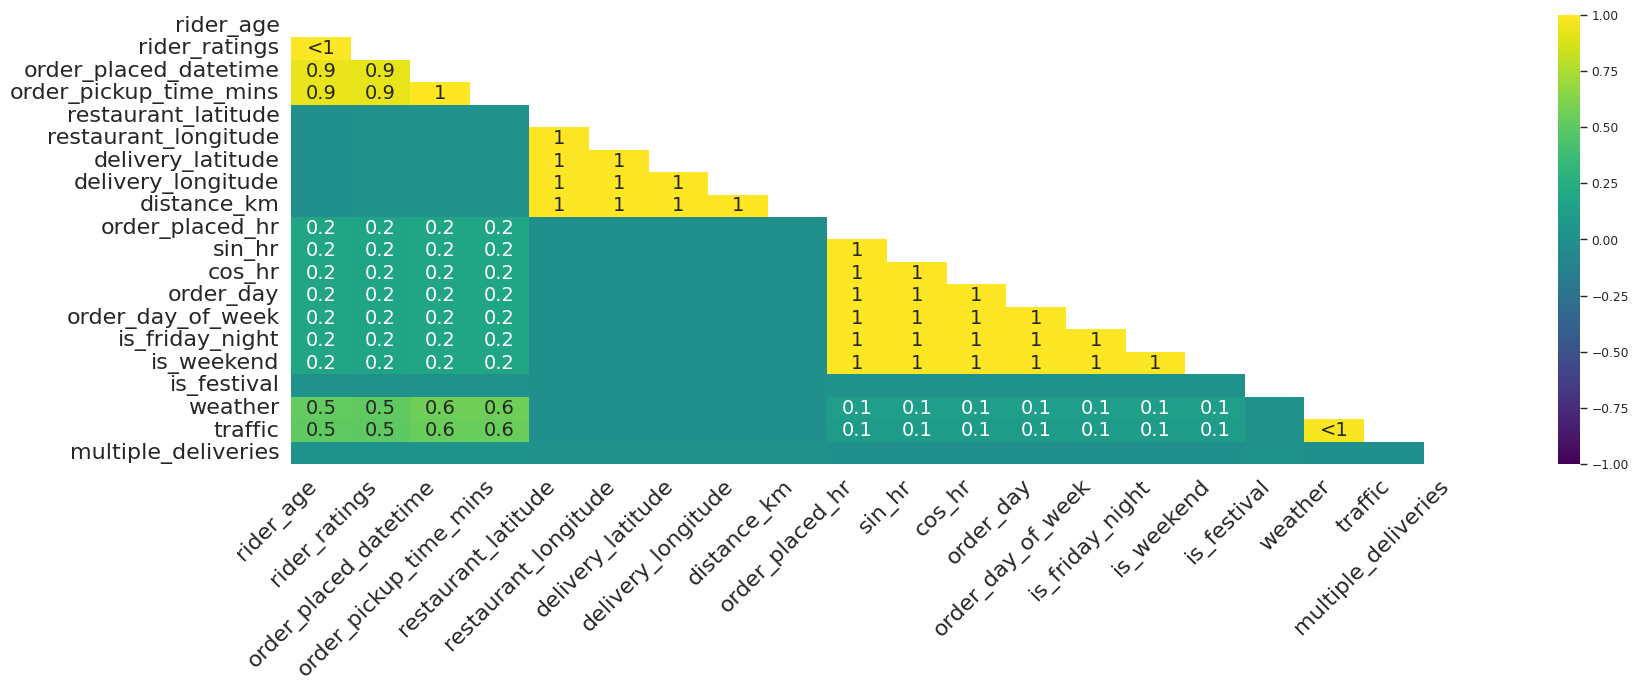

In [21]:
fig,ax = plt.subplots(nrows = 1, ncols = 1, figsize = (18,7))
msno.heatmap(X, ax = ax, cmap = 'viridis')
plt.tight_layout()
plt.show()

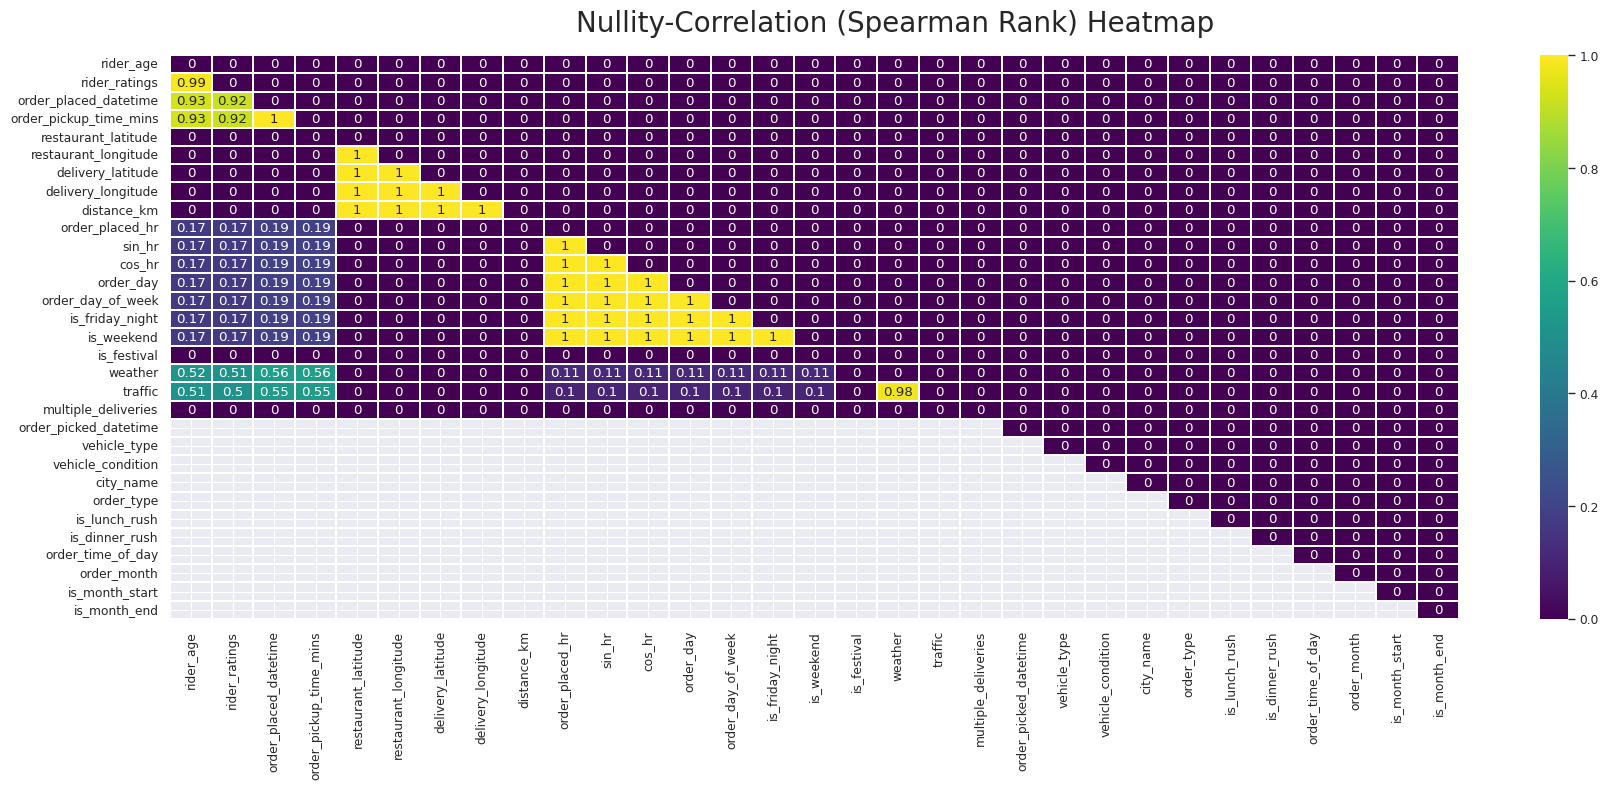

In [22]:
# ==============================================================================
# STEP 1 : Analyze correlation between missing-value patterns of columns
# ==============================================================================

# Convert the dataframe into a binary missing-value indicator matrix:
#     1 -> value is missing (NaN)
#     0 -> value is present (not NaN)
#
# Example:
# Original:
#     Age   Salary
#     25    NaN
#     NaN   50000
#
# After df.isnull().astype(int):
#     Age   Salary
#      0      1
#      1      0
#
# Then calculate the Spearman correlation between these binary missingness indicators.
# Positive correlation: Missingness in both columns tends to occur together.
# Negative correlation: When one value column is missing, the value in other tends to be present.
# Correlation near 0: There is little /no linear / no monotonic relationship between their missing-value patterns.
corr_matrix = X.isnull().astype(int).corr(method = 'spearman').round(2)

# ==============================================================================
# STEP 2 : Store column labels for rebuilding the DataFrame later
# ==============================================================================

# corr_matrix.columns.tolist() creates a Python list containing all column names.
#
# Multiplying the list container by 2 creates two separate lists having the same labels:
#
# corr_columns -> labels for DataFrame columns
# corr_index   -> labels for DataFrame rows
#
# This is useful because np.where() and np.tril() return NumPy
# arrays and therefore do not preserve pandas row/column labels.
corr_columns, corr_index = [corr_matrix.columns.tolist()]*2

# ==============================================================================
# STEP 3 : Remove very weak / approximately zero correlations
# ==============================================================================
#
# If a correlation becomes 0 after rounding to 1 decimal place,
# np.where() explicitly replaces it with 0.
#
# Otherwise, the original correlation value from corr_matrix.values
# is retained.
#
# Example:
#     0.03  -> round(0.003, 1) = 0.0 -> replaced with 0
#     0.26  -> round(0.26, 1) = 0.3 -> original 0.26 retained
#
# This makes the heatmap cleaner by suppressing extremely weak
# correlations that are unlikely to be visually useful.
corr_matrix = np.where(np.round(corr_matrix,1) == 0, 0, corr_matrix)

# ==============================================================================
# STEP 4 : Keep only the lower triangular part of the correlation matrix
# ==============================================================================

# A correlation matrix is symmetric: corr(A, B) = corr(B, A)
#
# Therefore, the values above and below the main diagonal contain
# duplicate information.
#
# np.tril(k = -1) keeps:
# - all values below the diagonal
# - and replaces all values above the diagonal with 0.
#
# This avoids displaying the same pairwise correlation twice
# and makes the heatmap easier to read.
corr_matrix = pd.DataFrame(data = np.tril(corr_matrix, k = -1), columns = corr_columns, index = corr_index)

# Plotting correlation heatmap
fig_nullity = plt.figure(figsize = (18,8))
fig_nullity.suptitle('Nullity-Correlation (Spearman Rank) Heatmap', fontsize = 20)
sns.heatmap(corr_matrix, annot = True, cmap = 'viridis', linewidths = 0.01)
plt.tight_layout()
plt.show()

### Observations

---

## Strongly Correlated Missingness Blocks

### Block 1: Rider / Order-Time Related Features

The following variables show very strong positive nullity correlations:

- `rider_age` & `rider_ratings` => approximately `0.99`
- `rider_age` & `order_placed_datetime` => approximately `0.93`
- `rider_ratings` & `order_placed_datetime` => approximately `0.92`

### Interpretation

1. The missingness patterns of `rider_age`, `rider_ratings`, `order_placed_datetime` are very strongly associated.

2. In particular, the near-perfect correlation between `rider_age` and `rider_ratings` indicates that these two features become missing together in almost the same observations.

3. Together, these results indicate a strong **block-wise missingness structure** involving rider-related information and order-time-related information.

4. A possible domain hypothesis is that these variables may share a common data-generation or data-capture process. For example, a logging, synchronization, API, or data-collection failure could potentially cause multiple related values to be unavailable for the same observations.

5. However, this is only a hypothesis based on the observed missingness structure. Nullity correlation alone cannot identify the actual cause of missingness.

6. Most importantly, strong block-wise missingness does **not automatically prove that the mechanism is non-MCAR**.

   For example, if a completely random system failure causes all four variables to become missing together, while the failure itself is unrelated to the actual observed or unobserved values, the mechanism could still be compatible with MCAR.

7. Therefore, from nullity correlation alone, we can conclude:

   - There is strong structured block-wise missingness.
   - The features are very likely influenced by a common missing-data process.
   - Their missingness indicators are strongly associated.

   But we cannot conclude from this analysis alone whether the mechanism is:

   - MCAR
   - MAR
   - MNAR

8. Additional analysis, such as missingness-prediction experiments and domain knowledge, is required to investigate the likely missingness mechanism.

---

## Important Correction Regarding MNAR

A technical or network problem does **not automatically imply MNAR**.

MNAR specifically means that:

> The probability that a value is missing depends on the actual unobserved value itself, even after considering the observed information.

For example:

If very low `rider_ratings` are more likely to be hidden specifically because the true rating is low, then:

True low rider rating
        ↓
Higher probability of rating being missing

This would be consistent with MNAR.

However, if a random technical glitch causes `rider_age`, `rider_ratings`, and order-time information to disappear together, that does not by itself imply MNAR.

Therefore, the statement:

"Missingness may be MNAR because there is some technical reason why the values are missing"

is NOT sufficient.

The reason must specifically depend on the unavailable value itself for the mechanism to be considered MNAR.

---

## Block 2: Weather and Traffic

The nullity correlation between:

- `weather`
- `traffic`

is approximately `0.98`, which represents a very strong positive missingness association.

### Interpretation

1. `weather` and `traffic` have almost identical missingness patterns.

2. When `weather` is missing, `traffic` is also very frequently missing, and vice versa.

3. This indicates a strong co-missingness relationship between the two variables.

4. One possible explanation is that weather and traffic information may originate from the same or related external data source, API, logging system, or data-collection process.

5. However, this explanation cannot be confirmed from the heatmap alone.

6. The strong nullity correlation establishes:

   - Strong pairwise co-missingness
   - Structured missingness between these variables
   - A possible common missing-data process

7. It does NOT establish:

   - MCAR
   - MAR
   - MNAR
   - The actual cause of missingness

8. Therefore, additional investigation is required to understand the underlying missingness mechanism.

---

# Moderately Correlated Missingness Relationships

The following pairs show moderate positive nullity correlations:

- `order_placed_datetime` & `weather` → approximately `0.56`
- `order_pickup_time_mins` & `weather` → approximately `0.56`
- `order_placed_datetime` & `traffic` → approximately `0.55`
- `order_pickup_time_mins` & `traffic` → approximately `0.55`

These correlations indicate a moderate association between the missingness of order-time-related variables and environmental variables.

### Interpretation

1. When an order-time-related feature is missing, weather or traffic information tends to be missing more often than would be expected under pairwise independence.

2. However, the relationship is substantially weaker than the near-perfect relationships observed within the major missingness blocks.

3. Therefore, these variables appear to have some shared missingness structure, but they do not have identical missingness patterns.

4. Correlation values around `0.55–0.56` should be interpreted as moderate pairwise missingness associations rather than as evidence that one variable will necessarily be missing whenever the other is missing.

5. These correlations alone cannot establish whether the missingness mechanism is MCAR, MAR, or MNAR.

---

## Rider-Related Features vs Weather / Traffic

The following relationships are also moderately positively correlated:

- `rider_age` & `weather` → approximately `0.52`
- `rider_age` & `traffic` → approximately `0.51–0.52`
- `rider_ratings` & `weather` → approximately `0.51`
- `rider_ratings` & `traffic` → approximately `0.50–0.51`

### Interpretation

1. These correlations suggest a moderate association between the missingness of rider-related variables and environmental variables.

2. In other words, observations where rider information is missing also show an increased tendency for weather or traffic information to be missing.

3. However, this relationship is considerably weaker than the near-perfect missingness relationships observed within:

   - the rider/order-time block
   - the weather/traffic block

4. This may suggest that the two blocks are partially connected through a broader data-collection process, but nullity correlation alone cannot establish such a causal explanation.

5. These correlations do not determine whether the missingness mechanism is MCAR, MAR, or MNAR.

## e. Final Interpretation

1. The missingness in this dataset appears systematic and dependent on other features rather than being completely random.

2. Strong nullity correlations, matrix chart & dendrogram clustering indicate block-wise missingness patterns.

3. However, while the missingness structure **suggests systematic missingness**, the analysis **does not definitively prove MCAR, MAR, MNAR**

4. Ultimately, the optimal strategy to impute missing values should be determined through experimentation and model performance evaluation.

In [23]:
t1 = get_missing_info(train_df)
t2 = get_missing_info(test_df)

pd.concat([t1,t2], axis = 1)

,feature,data_type,missing_count,missing_%,feature,data_type,missing_count,missing_%
0,rider_age,float64,1502,4.13,rider_age,float64,351,3.86
1,rider_ratings,float64,1541,4.23,rider_ratings,float64,366,4.02
2,multiple_deliveries,float64,808,2.22,multiple_deliveries,float64,185,2.03
3,vehicle_type,object,0,0.00,vehicle_type,object,0,0.00
4,vehicle_condition,object,0,0.00,vehicle_condition,object,0,0.00
5,city_name,object,0,0.00,city_name,object,0,0.00
6,restaurant_latitude,float64,2854,7.84,restaurant_latitude,float64,776,8.53
7,restaurant_longitude,float64,2854,7.84,restaurant_longitude,float64,776,8.53
8,delivery_latitude,float64,2854,7.84,delivery_latitude,float64,776,8.53
9,delivery_longitude,float64,2854,7.84,delivery_longitude,float64,776,8.53


In [24]:
train_df.drop(columns = ['order_placed_datetime', 'order_picked_datetime'], inplace = True)
test_df.drop(columns =  ['order_placed_datetime', 'order_picked_datetime'], inplace = True)

In [25]:
X_train = train_df.drop(columns = ['time_taken'])
y_train = train_df['time_taken']

X_test = test_df.drop(columns = ['time_taken'])
y_test = test_df['time_taken']

In [26]:
y_train.isnull().sum()

np.int64(0)

In [27]:
y_test.isnull().sum()

np.int64(0)

# Why should we don't use Compelete Case Analysis (CCA) ?

In [28]:
original_rows =  len(X_train)
after_removing = len(X_train.dropna())

# If we remove all NaN Values
dropped_percentage = round(((original_rows - after_removing)/original_rows) * 100,2)

print(f'Amount of data dropped if we use Compelte Case Analysis(CCA): {dropped_percentage}%')

Amount of data dropped if we use Compelte Case Analysis(CCA): 14.08%


When to perform CCA / Listwise deletion ?

1. Use CCA => when after applying it only <=5% of total rows from the data is deleted. This is the only threshold you should keep in mind.

2. It should preserve distribution of data before and after dropping rows.

Important Reminder:

---
**MCAR Definition**

MCAR (Missing Completely at Random) means:
- The probability of data being missing is the same for all observations
- It does not depened either on the observed data neither it depends on the unobserved (missing) data.
- The missingness is completely random and has no relationship with any other data, making MCAR is the simplest case to handle since it introduces least bias.

---
**MAR Definition**

MAR (Missing at Random) means:
- The probability of data being missing is related to the observed data but not to the unobserved data.
- The Missingness can be explained by the **other variables in the dataset for which data is available**.
- Under MAR, Missingness is systematic and can be modelled using the observed data

---
**MNAR Definition**

MNAR (Missing Not at Random) means:
- The probability of data being missing is related to the unobserved data itself.
- The missingness depends on the missing data, meaning there's is a reason related to the missing values that explain why they're missing.

#  Identify Mechanism of Missingness
- To check for MAR like Evidence

In [29]:
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [30]:
derived_from_datetime_cols = ['order_pickup_time_mins', 'order_placed_hr', 'sin_hr', 'cos_hr',
                              'order_time_of_day', 'is_lunch_rush', 'is_dinner_rush', 'order_day', 'order_day_of_week', 'is_friday_night',
                              'is_weekend', 'order_month', 'is_month_start', 'is_month_end']

In [31]:
get_missing_info(X_train[derived_from_datetime_cols])

,feature,data_type,missing_count,missing_%
0,order_pickup_time_mins,float64,1319,3.62
1,order_placed_hr,float64,47,0.13
2,sin_hr,float64,47,0.13
3,cos_hr,float64,47,0.13
4,order_time_of_day,object,0,0.00
5,is_lunch_rush,boolean,0,0.00
6,is_dinner_rush,boolean,0,0.00
7,order_day,float64,47,0.13
8,order_day_of_week,object,47,0.13
9,is_friday_night,boolean,47,0.13


In [32]:
cols_for_mar = ['rider_age', 'rider_ratings', 'multiple_deliveries', 'vehicle_type', 'vehicle_condition', 'city_name',
                'distance_km', 'order_type', 'order_pickup_time_mins', 'order_placed_hr', 'is_festival', 'weather', 'traffic']

In [33]:
X_train_mar = X_train[cols_for_mar]
X_test_mar = X_test[cols_for_mar]

In [34]:
# ==============================================================================
# CHECKING FOR MAR-LIKE EVIDENCE USING MISSINGNESS PREDICTION
# ==============================================================================
#
# Idea: For every feature that contains missing values, create a temporary
# binary classification problem:
#
#     1 -> value is missing
#     0 -> value is present
#
# Then use all the OTHER observed features to predict the missingness in the
# selected feature. If the missingness can be predicted reasonably well on
# unseen test data, it provides evidence that the missingness is associated
# with other observed variables.
#
# This is consistent with MAR-like behaviour, although it does NOT
# mathematically prove that the data is MAR.

# ==============================================================================
# Select only those columns that contain at least one missing value.
#
# These are the features whose missingness mechanism we want to investigate.
# ==============================================================================
mask = X_train_mar.isnull().sum()
nullity_cols = mask[mask>0].index.tolist()

# Store the F1 scores obtained for every missing-value feature.
results = []

# ==============================================================================
# INVESTIGATE EACH FEATURE CONTAINING MISSING VALUES
# ==============================================================================
for i in nullity_cols:

    print(f'Missingness in: "{i}"')
    # ==========================================================================
    # DEFINE FEATURE GROUPS
    # ==========================================================================
    #
    # These lists are created again inside every iteration
    # because the current feature 'i' must be removed from
    # whichever feature group it belongs to.
    #
    # Creating fresh lists prevents changes made during one
    # iteration from affecting the next iteration.

    # Numerical features
    numerical_cols = ['rider_age', 'rider_ratings', 'multiple_deliveries', 'distance_km', 'order_pickup_time_mins', 'order_placed_hr']

    # Boolean / binary indicator features
    boolean_cols = ['is_festival']

    # Nominal categorical features that will be One-Hot Encoded
    ohe_cols = 	['vehicle_type', 'city_name', 'order_type', 'weather']

    # Ordinal categorical features whose categories have a meaningful order
    ordinal_cols = 	['vehicle_condition', 'traffic']

    # Define the explicit ordering of ordinal categories.
    #
    # OrdinalEncoder will convert these ordered categories into numerical values while preserving their order.
    ordinal_categories_map = {'vehicle_condition': ['0','1','2','3'], 'traffic': ['Low', 'Medium', 'High', 'Jam']}

    # ==========================================================================
    # REMOVE THE FEATURE WHOSE MISSINGNESS IS BEING PREDICTED
    # ==========================================================================
    #
    # Suppose: i = 'rider_age'
    #
    # Our target will become: Is rider_age missing?
    #
    # Therefore, rider_age itself should NOT be included among
    # the predictor variables.
    #
    # Otherwise, information from the feature whose missingness
    # we are trying to predict could enter the model.
    if i in numerical_cols:
       numerical_cols.remove(i)

    elif i in boolean_cols:
         boolean_cols.remove(i)

    elif i in ohe_cols:
         ohe_cols.remove(i)

    elif i in ordinal_cols:
         ordinal_cols.remove(i)

         # If the target feature is ordinal, also remove its
         # category ordering because that feature will no longer
         # be passed to OrdinalEncoder.
         ordinal_categories_map.pop(i)

    # ==========================================================================
    # CREATE PREPROCESSING PIPELINES
    # ==========================================================================
    #
    # Other predictor features may themselves contain missing values.
    #
    # RandomForestClassifier cannot work with these missing
    # predictor values directly in this workflow, so we
    # temporarily impute them using the mean for numerical otherwise mode.
    #
    # Important:
    # The purpose of this imputation is NOT to permanently decide how
    # missing values should be handled in the final prediction model.
    #
    # It simply allows us to use the remaining variables to
    # predict the missingness in feature 'i'.

    # ==========================================================================
    # CATEGORICAL PREPROCESSING
    # ==========================================================================
    #
    # Step 1:
    # Replace missing categorical values using the most frequently occurring
    # category from the TRAINING data.
    #
    # Step 2:
    # Convert nominal categorical variables into binary One-Hot Encoded columns.
    ohe_preprocessor = Pipeline(steps = [('Imputation', SimpleImputer(strategy = 'most_frequent')),
                                         ('OHE', OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore'))
                                        ])

    ordinal_preprocessor = Pipeline(steps = [('Imputation', SimpleImputer(strategy = 'most_frequent')),
                                             ('Ordinal_Encoding', OrdinalEncoder(categories = list(ordinal_categories_map.values()), dtype = int,
                                                                                 handle_unknown = 'use_encoded_value', unknown_value = -999))])

    trf_applied = [('numerical_preprocessing', SimpleImputer(strategy = 'mean'), numerical_cols),
                   ('boolean_preprocessing',   SimpleImputer(strategy = 'most_frequent'), boolean_cols),
                   ('one_hot_preprocessing',   ohe_preprocessor, ohe_cols),
                   ('ordinal_preprocessing',   ordinal_preprocessor, ordinal_cols)]

    preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'drop', n_jobs = -1)

    # Final Pipeline
    model_pipe = Pipeline(steps = [('Preprocessing', preprocessing),
                                   ('Classifier', RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42, n_jobs = -1))])

    # Training Data for Pipeline
    X_train_trf = X_train_mar.drop(columns = [i])
    y_train_trf = X_train_mar[i].isnull().astype(int) # 1 => missing, 0 => not missing

    # 1. Evaluate your model's stability using cross-validation on the training set
    stratified_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
    train_cv_scores = cross_val_score(estimator = model_pipe, X = X_train_trf, y = y_train_trf, cv = stratified_cv, scoring = 'f1_macro')
    train_mean_score = train_cv_scores.mean()

    # 2. Creating Training Data for classifier
    X_train_trf = preprocessing.fit_transform(X_train_mar.drop(columns = [i]))
    y_train_trf = X_train_mar[i].isnull().astype(int)

    # 3. Creating Test Data for classifier
    X_test_trf = preprocessing.transform(X_test_mar.drop(columns = [i]))
    y_test_trf = X_test_mar[i].isnull().astype(int)

    # 4. Train the final model on the ENTIRE training dataset
    classifier = model_pipe.named_steps['Classifier']
    classifier.fit(X_train_trf, y_train_trf)

    # 5. Predict on the completely unseen test dataset
    y_test_pred = classifier.predict(X_test_trf)

    # 6. Calculate the true test score using the actual vs predicted labels
    test_score = f1_score(y_test_trf, y_test_pred, average = 'macro')

    # 7. Appending results
    results.append([i, train_mean_score, test_score])

Missingness in: "rider_age"
Missingness in: "rider_ratings"
Missingness in: "multiple_deliveries"
Missingness in: "distance_km"
Missingness in: "order_pickup_time_mins"
Missingness in: "order_placed_hr"
Missingness in: "is_festival"
Missingness in: "weather"
Missingness in: "traffic"


In [35]:
result_df = pd.DataFrame(data = results, columns = ['Nullity features', 'Train_F1_macro(avg)', 'Test(Unseen)_F1_macro'])
result_df.sort_values(by = 'Test(Unseen)_F1_macro', inplace = True, ascending = False, ignore_index = True)
result_df

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,rider_age,0.983706,0.988933
1,rider_ratings,0.985872,0.986133
2,order_pickup_time_mins,0.961696,0.975207
3,weather,0.950036,0.948424
4,traffic,0.957338,0.944389
5,distance_km,0.620423,0.627451
6,order_placed_hr,0.517859,0.499725
7,is_festival,0.498740,0.498705
8,multiple_deliveries,0.494388,0.494865


Observations

- Except 4 nullity features `distance_km`, `order_placed_hr`, `is_festival`, `multiple_deliveries` rest of the nullity features shows strong **MAR like evidence**

In [36]:
result_df.to_csv('6. MAR-like-evidence.csv', index = False)

In [37]:
mar_evidence_df = pd.read_csv('/content/6. MAR-like-evidence.csv')
mar_evidence_df

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,rider_age,0.983706,0.988933
1,rider_ratings,0.985872,0.986133
2,order_pickup_time_mins,0.961696,0.975207
3,weather,0.950036,0.948424
4,traffic,0.957338,0.944389
5,distance_km,0.620423,0.627451
6,order_placed_hr,0.517859,0.499725
7,is_festival,0.498740,0.498705
8,multiple_deliveries,0.494388,0.494865


# Deciding Imputation technique for Nullity Features

In [38]:
def check_for_imputation_type(feature_name:str, data_type:str) -> None:

    temp = get_missing_info(X_train)
    display(temp[temp['feature'] == feature_name].reset_index(drop = True))

    if data_type == 'numerical':

       print('\n\n Unique Value:', sorted(X_train[feature_name].unique().tolist()), end = '\n\n')

       fig,(ax_before, ax_after) = plt.subplots(nrows = 1, ncols = 2, figsize = (16,5))
       fig.suptitle('Change in Distribution Before & After Mean Imputation', fontsize = 14)

       # ----------------------------------------------Before Imputation -----------------------------------------------

       # Probability Density Function
       sns.kdeplot(X_train[feature_name].dropna(), label = 'Before Imputation', color = 'red', ax = ax_before)

       # For plotting vertical lines
       mean =   X_train[feature_name].mean().round(2)
       median = X_train[feature_name].median()

       ax_before.axvline(x = mean,   color = 'black', linestyle = '--', label = f'Mean: {mean}')
       ax_before.axvline(x = median, color = 'blue',  linestyle = '--', label = f'Median: {median}')

       # Labelling & Spacing
       ax_before.set_title('Before Imputation', fontsize = 12)
       ax_before.legend()

       # ---------------------------------------------After Imputation ---------------------------------------------------

       mean_temp = X_train[feature_name].fillna(X_train[feature_name].mean())
       median_temp = X_train[feature_name].fillna(X_train[feature_name].median())
       temp = pd.concat([mean_temp,median_temp], axis = 1)
       temp.columns = [f'{feature_name}_imputed_mean', f'{feature_name}_imputed_median']

       # Probability Density Function
       sns.kdeplot(X_train[feature_name].dropna(), label = 'Before Imputation', color = 'red', ax = ax_after)
       sns.kdeplot(data = temp, x = f'{feature_name}_imputed_mean',    label = 'After Mean Imputation',   color = 'black', ax = ax_after)
       sns.kdeplot(data = temp, x = f'{feature_name}_imputed_median' , label = 'After Median Imputation', color = 'blue',  ax = ax_after)

       # For plotting Vertical Lines
       mean = temp[f'{feature_name}_imputed_mean'].mean().round(2)
       median = temp[f'{feature_name}_imputed_median'].median()

       ax_after.axvline(x = mean,   color = 'black', linestyle = '--', label = f'Mean: {mean}')
       ax_after.axvline(x = median, color = 'blue',  linestyle = '--', label = f'Median: {median}')

       # Labelling & Spacing
       ax_after.set_title('After Imputation', fontsize = 12)
       ax_after.legend()
       plt.tight_layout()
       plt.show()


    elif data_type == 'categorical':

         print('\n\n Unique Value:', X_train[feature_name].unique().tolist(), end = '\n\n')

         fig, (ax_before, ax_after) = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
         fig.suptitle('Change in Distribution Before & After Mode Imputation', fontsize = 14)

         # Before Imputation
         sns.countplot(data = X_train, x = feature_name, hue = feature_name, stat = 'proportion', ax = ax_before)
         ax_before.set_title('Before Imputation')
         ax_before.set_ylabel('Proportion')
         ax_before.set_xlabel(feature_name)

         # After Imputation
         mode = X_train[feature_name].mode()[0]
         temp = X_train[feature_name].fillna(mode)

         sns.countplot(x = temp, hue = temp, stat = 'proportion', ax = ax_after)
         ax_after.set_title('After Imputation')
         ax_after.set_ylabel('Proportion')
         ax_after.set_xlabel(feature_name)
         ax_after.legend()

         # Improve Spacing
         plt.tight_layout()
         plt.show()


    elif data_type =='boolean':

         print('\n\n Unique Value:', X_train[feature_name].unique().tolist(), end = '\n\n')

         fig, (ax_before, ax_after) = plt.subplots(nrows = 1, ncols = 2, figsize = (12,5))
         fig.suptitle('Change in Distribution Before & After Mode Imputation', fontsize = 14)

         # Before Imputation
         sns.countplot(data = X_train.dropna(), x = feature_name, hue = feature_name, stat = 'proportion', ax = ax_before)

         # After Imputation
         mode = X_train[feature_name].mode().values[0]
         temp = X_train[feature_name].fillna(mode).reset_index()
         sns.countplot(data = temp, x = feature_name, hue = feature_name, stat = 'proportion', ax = ax_after)

         # Improve Spacing
         plt.tight_layout()
         plt.show()


    # Fetch data from mcar_evidence_df
    print('\n\n')
    display(mar_evidence_df[mar_evidence_df['Nullity features'] == feature_name].reset_index(drop = True))

## 1.Numerical feature

### a. rider_age

,feature,data_type,missing_count,missing_%
0,rider_age,float64,1502,4.13




 Unique Value: [20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, nan]



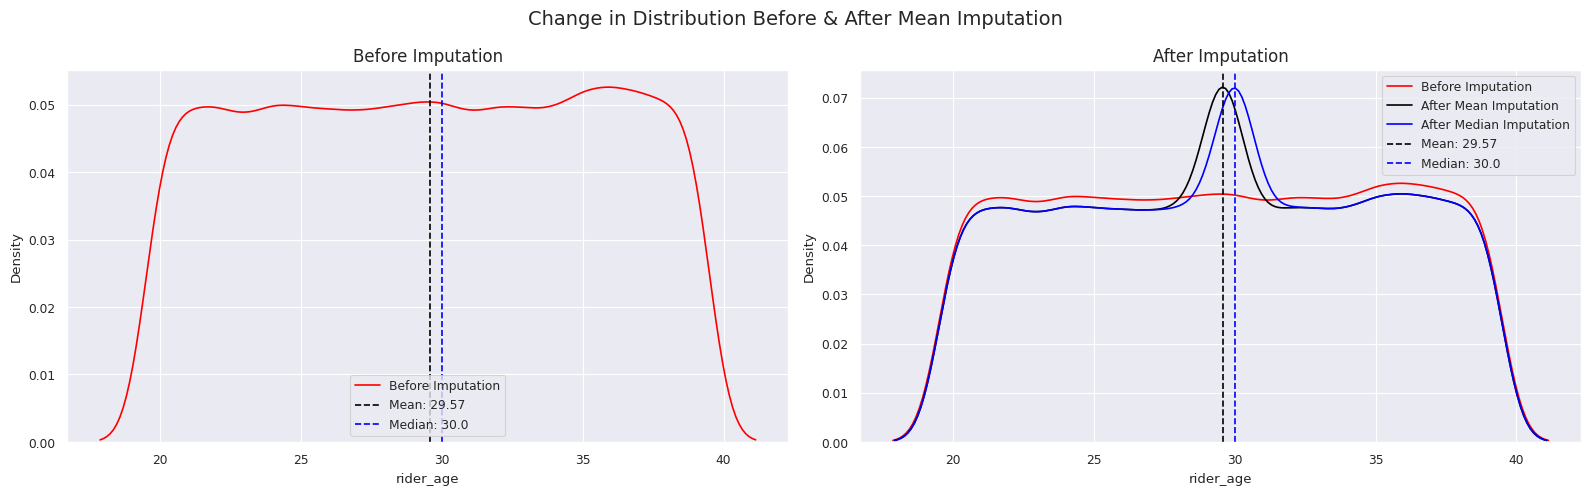

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,rider_age,0.983706,0.988933


In [39]:
check_for_imputation_type(feature_name = 'rider_age', data_type = 'numerical')

Observations

---
- `rider_age` is a **discrete numerical feature** with observed values ranging from 20 to 39. Since the original values are whole numbers, mean imputation can introduce fractional values that do not naturally belong to the original feature domain.

- From the distribution analysis, both **mean and median imputation create an artificial concentration of observations around the center of the distribution**. The original distribution is relatively even across the observed age range, while constant-value imputation creates a noticeable peak near the mean/median.

- Therefore, although mean and median imputation are simple approaches, they slightly distort the original distribution of `rider_age` by assigning the same value to all missing observations.

- `rider_age` shows strong **block-wise co-missingness** with `rider_ratings` and `order_pickup_time_mins`. This means that these variables frequently become missing together and may be affected by a common data-capture or data-generation process.

- However, this block-wise co-missingness only describes the **structure of the missingness**. It does not by itself determine whether the missing-data mechanism is MCAR, MAR, or MNAR.

- In the MAR-like evidence experiment, the missingness of `rider_age` was highly predictable on both training and unseen data:
  - Train Macro-F1: `0.98`
  - Test Macro-F1: `0.98`

- The strong out-of-sample missingness-prediction performance indicates that the **occurrence of missingness is systematically associated with information available in the dataset**. Therefore, `rider_age` shows strong **MAR-like evidence**, although this does not formally prove that the true missingness mechanism is MAR.

- It is important to distinguish between **predicting whether `rider_age` is missing** and **predicting what the actual missing `rider_age` value should be**. These are two different prediction problems:
  - **Missingness modeling:** Can we predict whether `rider_age` is missing?
  - **Value imputation:** Given that `rider_age` is missing, can we estimate whether its true value should be 26, 29, 30, 31, etc.?

- Strong multivariate missingness structure only tells us that the **patterns of missingness are related across variables**. For example, `rider_age`, `rider_ratings`, and `order_pickup_time_mins` may frequently become missing together, but it does not by itself prove that these variables can accurately predict the actual missing value of `rider_age`.

- Similarly, strong MAR-like evidence does not automatically imply that a multivariate imputation method must be used. It tells us that the **occurrence of missingness** can be explained to some extent using observed information, not that the actual missing value can necessarily be predicted accurately from the same variables.

- Therefore, the strong co-missingness of `rider_age` with `rider_ratings` and `order_pickup_time_mins` does not mean that only these two features should be used to estimate missing `rider_age` values.

- For value imputation, other numerical features may still contain useful predictive information about the actual `rider_age` values, even if those features are not strongly associated with the missingness pattern.

- The suitability of `IterativeImputer` or `KNNImputer` therefore depends on whether the available numerical features contain useful information for estimating the actual missing values of `rider_age`.

- If multivariate imputation methods such as `IterativeImputer` or `KNNImputer` are evaluated, **all relevant numerical features can be considered**, rather than restricting the imputation model only to `rider_ratings` and `order_pickup_time_mins`.

- Reasonable candidate imputation strategies for `rider_age` include:
  - `IterativeImputer`
  - `KNNImputer`

- These candidate methods can also be evaluated **with and without missing indicators**, because the fact that `rider_age` was originally missing may itself contain useful predictive information for the model.

- The final imputation strategy should be selected empirically using **cross-validated model performance**, comparing metrics such as R², MAE rather than selecting an imputation method solely from the missingness-pattern analysis.

### b. rider_ratings

,feature,data_type,missing_count,missing_%
0,rider_ratings,float64,1541,4.23




 Unique Value: [2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, nan]



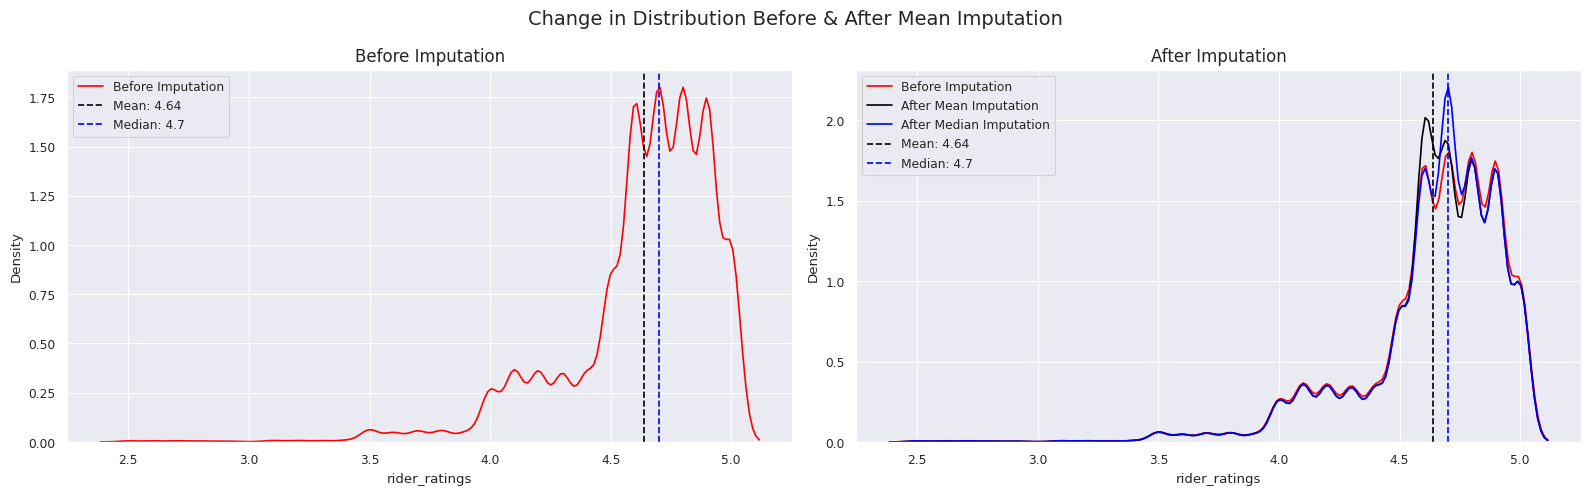

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,rider_ratings,0.985872,0.986133


In [40]:
check_for_imputation_type(feature_name = 'rider_ratings', data_type = 'numerical')

Observations

---
- `rider_ratings` is a **numerical feature** with observed values ranging approximately from `2.5` to `5.0`, mostly occurring in increments of `0.1`.

- Although `rider_ratings` is numerical, its observed values lie on a restricted rating scale rather than being completely unrestricted continuous values.

- From the distribution analysis, both **mean and median imputation create an artificial concentration of observations around the central region of the distribution**.

- Therefore, although mean and median imputation are simple approaches, assigning the same central value to all missing observations slightly distorts the original distribution of `rider_ratings`.

- `rider_ratings` shows strong **block-wise co-missingness** with `rider_age` and `order_pickup_time_mins`. This means that these variables frequently become missing together and may be affected by a common data-capture or data-generation process.

- However, this block-wise co-missingness only describes the **structure of the missingness**. It does not by itself determine whether the missing-data mechanism is MCAR, MAR, or MNAR.

- In the MAR-like evidence experiment, the missingness of `rider_ratings` was highly predictable on both training and unseen data:
  - Train Macro-F1: `0.98`
  - Test Macro-F1: `0.98`

- The strong out-of-sample missingness-prediction performance indicates that the **occurrence of missingness is systematically associated with information available in the dataset**.

- Therefore, `rider_ratings` shows strong **MAR-like evidence**, although this does not formally prove that the true missingness mechanism is MAR.

- It is important to distinguish between **predicting whether `rider_ratings` is missing** and **predicting what the actual missing `rider_ratings` value should be**. These are two different prediction problems:
  - **Missingness modeling:** Can we predict whether `rider_ratings` is missing?
  - **Value imputation:** Given that `rider_ratings` is missing, can we estimate whether its true value should be `4.2`, `4.5`, `4.7`, `4.9`, etc.?

- Strong multivariate missingness structure only tells us that the **patterns of missingness are related across variables**. For example, `rider_ratings`, `rider_age`, and `order_pickup_time_mins` may frequently become missing together, but this does not by itself prove that these variables can accurately predict the actual missing value of `rider_ratings`.

- Similarly, strong MAR-like evidence does not automatically imply that a multivariate imputation method must be used. It tells us that the **occurrence of missingness** can be explained to some extent using observed information, not that the actual missing rating value can necessarily be predicted accurately from the same information.

- The strong co-missingness of `rider_ratings` with `rider_age` and `order_pickup_time_mins` does not mean that only these two features should be used to estimate missing `rider_ratings` values.

- For value imputation, other numerical features may still contain useful predictive information about the actual `rider_ratings` values, even if those features are not strongly associated with the missingness pattern.

- The suitability of `IterativeImputer` or `KNNImputer` therefore depends on whether the available numerical features contain useful information for estimating the actual missing values of `rider_ratings`.

- If multivariate imputation methods such as `IterativeImputer` or `KNNImputer` are evaluated, **all relevant numerical features can be considered**, rather than restricting the imputation model only to `rider_age` and `order_pickup_time_mins`.

- Reasonable candidate imputation strategies for `rider_ratings` include:
  - `IterativeImputer`
  - `KNNImputer`

---
- Since `rider_ratings` normally occurs in approximately `0.1` increments, if a multivariate imputer generates values with excessive decimal precision, the imputed values can optionally be rounded to one decimal place so that they remain consistent with the observed feature scale.

- However, rounding should be treated as a domain-consistency post-processing step and should also be checked empirically rather than assumed to improve model performance.
---

- These candidate methods can also be evaluated **with and without missing indicators**, because the fact that `rider_ratings` was originally missing may itself contain useful predictive information for the model.

- The final imputation strategy should be selected empirically using **cross-validated model performance**, comparing metrics such as R² and MAE rather than selecting an imputation method solely from the missingness-pattern analysis.

### c. order_pickup_time_mins

,feature,data_type,missing_count,missing_%
0,order_pickup_time_mins,float64,1319,3.62




 Unique Value: [5.0, nan, 10.0, 15.0]



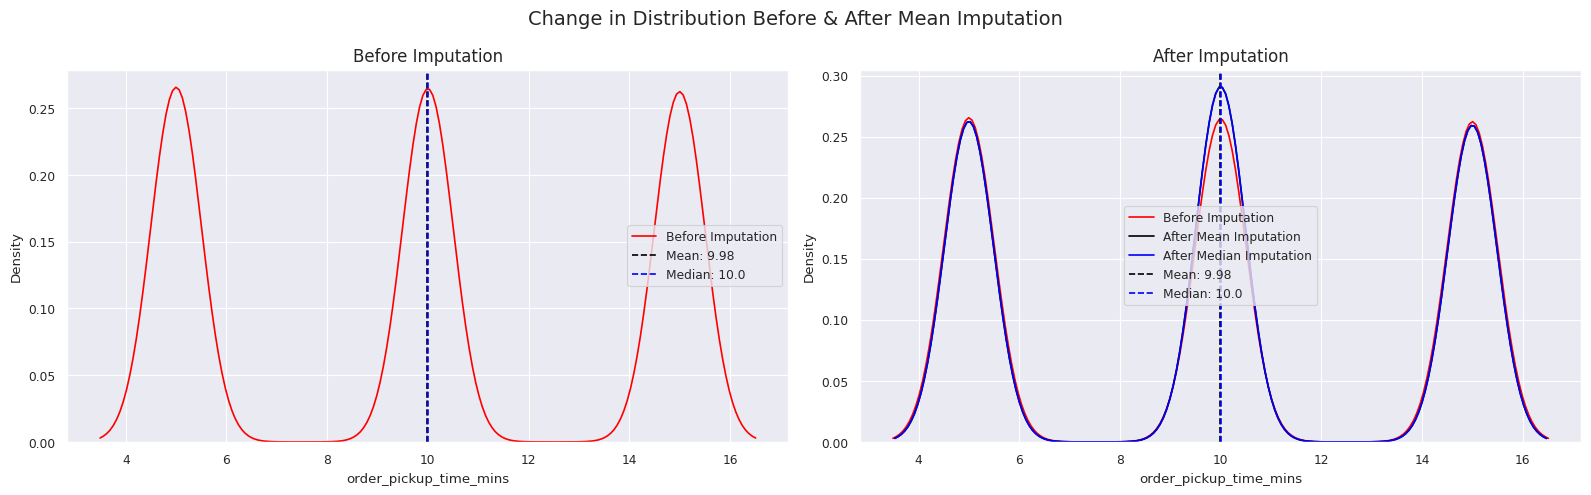

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,order_pickup_time_mins,0.961696,0.975207


In [41]:
check_for_imputation_type(feature_name = 'order_pickup_time_mins', data_type = 'numerical')

Observations

---

- `order_pickup_time_mins` is a **discrete numerical feature** with only three observed values: `5`, `10`, and `15` minutes.

- Since the original feature is restricted to these three values, mean imputation can introduce values that do not naturally belong to the original feature domain.

- From the distribution analysis, median imputation preserves a valid value (`10` minutes), but assigning the same value to every missing observation creates an artificial increase in the frequency of `10`.

- Therefore, although mean and median imputation are simple approaches, they can modify the original distribution of `order_pickup_time_mins`.

- `order_pickup_time_mins` shows strong **block-wise co-missingness** with `rider_age` and `rider_ratings`. This means that these variables frequently become missing together and may be affected by a common data-capture or data-generation process.

- However, this block-wise co-missingness only describes the **structure of the missingness**. It does not by itself determine whether the missing-data mechanism is MCAR, MAR, or MNAR.

- In the MAR-like evidence experiment, the missingness of `order_pickup_time_mins` was highly predictable on both training and unseen data:
  - Train Macro-F1: `0.96`
  - Test  Macro-F1: `0.971`

- The strong out-of-sample missingness-prediction performance indicates that the **occurrence of missingness is systematically associated with information available in the dataset**.

- Therefore, `order_pickup_time_mins` shows strong **MAR-like evidence**, although this does not formally prove that the true missingness mechanism is MAR.

- It is important to distinguish between **predicting whether `order_pickup_time_mins` is missing** and **predicting what the actual missing `order_pickup_time_mins` value should be**. These are two different prediction problems:
  - **Missingness modeling:** Can we predict whether `order_pickup_time_mins` is missing?
  - **Value imputation:** Given that `order_pickup_time_mins` is missing, can we estimate whether its true value should be `5`, `10`, or `15` minutes?

- Strong multivariate missingness structure only tells us that the **patterns of missingness are related across variables**. For example, `order_pickup_time_mins`, `rider_age`, and `rider_ratings` may frequently become missing together, but this does not by itself prove that these variables can accurately predict the actual missing value of `order_pickup_time_mins`.

- Similarly, strong MAR-like evidence does not automatically imply that a multivariate imputation method must be used. It tells us that the **occurrence of missingness** can be explained to some extent using observed information, not that the actual missing pickup-time value can necessarily be predicted accurately from the same information.

- Therefore, the strong co-missingness of `order_pickup_time_mins` with `rider_age` and `rider_ratings` does not mean that only these two features should be used to estimate missing `order_pickup_time_mins` values.

- For value imputation, other numerical features may still contain useful predictive information about the actual `order_pickup_time_mins` values, even if those features are not strongly associated with its missingness pattern.

- The suitability of `IterativeImputer` or `KNNImputer` therefore depends on whether the available numerical features contain useful information for estimating the actual missing values of `order_pickup_time_mins`.

- If multivariate imputation methods such as `IterativeImputer` or `KNNImputer` are evaluated, **all relevant numerical features can be considered**, rather than restricting the imputation model only to `rider_age` and `rider_ratings`.

- Reasonable candidate imputation strategies for `order_pickup_time_mins` include:
  - Mean/Median-based simple imputation as a baseline
  - `IterativeImputer`
  - `KNNImputer`

- Since the valid values of `order_pickup_time_mins` are restricted to `{5, 10, 15}`, a multivariate imputer may generate values outside this exact set, such as `8.4`, `11.7`, or `13.2`.

- Ordinary integer rounding would not completely solve this problem. For example, `12.7` would become `13`, which is still not a valid value for this feature.

- Therefore, if domain consistency is required, multivariate-imputed values can be mapped to the **nearest valid value among `{5, 10, 15}`**:
  - Values closest to `5` → `5`
  - Values closest to `10` → `10`
  - Values closest to `15` → `15`

- However, this nearest-valid-value mapping is a **domain-consistency post-processing step**. It should not be assumed beforehand to improve the final predictive model and can also be evaluated empirically.

- These candidate methods can also be evaluated **with and without missing indicators**, because the fact that `order_pickup_time_mins` was originally missing may itself contain useful predictive information for the model.

- The final imputation strategy should be selected empirically using **cross-validated model performance**, comparing metrics such as R² and MAE rather than selecting an imputation method solely from the missingness-pattern analysis.

### d. multiple_deliveries

,feature,data_type,missing_count,missing_%
0,multiple_deliveries,float64,808,2.22




 Unique Value: [0.0, 1.0, 2.0, 3.0, nan]



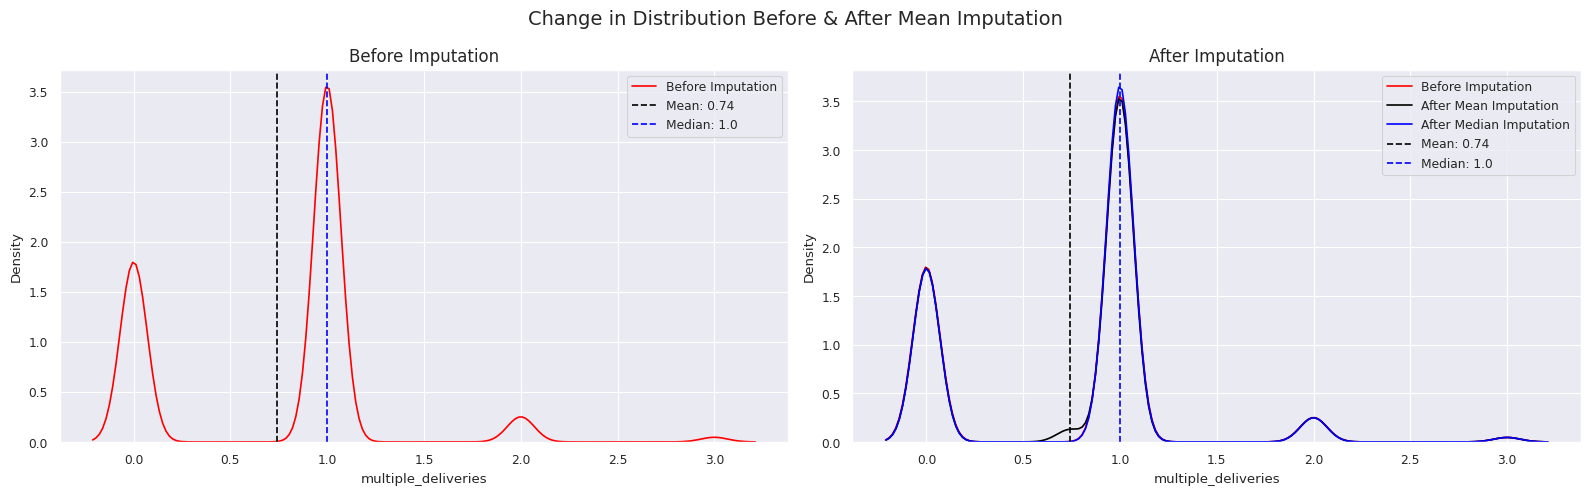

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,multiple_deliveries,0.494388,0.494865


In [42]:
check_for_imputation_type(feature_name = 'multiple_deliveries', data_type = 'numerical')

Observations:

---
- `multiple_deliveries` is a **discrete numerical feature** with observed values restricted to `0`, `1`, `2`, and `3`.

- Approximately **2.22%** of the observations in `multiple_deliveries` are missing.

- Since the original feature contains only the discrete values `{0, 1, 2, 3}`, mean imputation produces a value around `0.74`, which does not naturally belong to the original feature domain.

- Median imputation produces `1`, which is already a valid value in the original feature domain.

- From the distribution analysis, **median imputation appears to preserve the original distribution reasonably well**, although it slightly increases the concentration at `1` because every missing observation is assigned the same value.

- Therefore, `SimpleImputer(strategy='median')` is a reasonable simple baseline for this feature.

- The missingness indicator of `multiple_deliveries` shows approximately **zero Pearson and Spearman correlation** with the missingness indicators of the other features.

- This suggests that `multiple_deliveries` does not show a strong **pairwise co-missingness pattern** with the other variables in the dataset.

- However, near-zero nullity correlations do **not prove that the missingness is independent or MCAR**. They only indicate that strong pairwise relationships between its missingness and the missingness of other features were not detected.

- In the missingness-prediction experiment, the results were approximately:
  - Train Macro-F1: `0.49`
  - Test  Macro-F1: `0.49`

- These Macro-F1 scores are very low compared with the strong results observed for features such as `rider_age`, `rider_ratings`, and `order_pickup_time_mins`.

- Therefore, these results provide **little or no useful evidence that the missingness of `multiple_deliveries` can be predicted from the available observed information**.

- However, this does **not prove that the feature is MCAR**. **MCAR remains a plausible explanation**, but the available observational analysis cannot conclusively distinguish MCAR from all other possible missingness mechanisms.

- It is important to distinguish between **predicting whether `multiple_deliveries` is missing** and **predicting what the actual missing `multiple_deliveries` value should be**. These are two different prediction problems:
  - **Missingness modeling:** Can we predict whether `multiple_deliveries` is missing?
  - **Value imputation:** Given that `multiple_deliveries` is missing, can we estimate whether its true value should be `0`, `1`, `2`, or `3`?

- The fact that the missingness itself is difficult to predict does **not mean that other numerical features cannot help predict the actual value of `multiple_deliveries`**.

- For example, even if another feature does not explain why `multiple_deliveries` became missing, it may still have a useful relationship with the actual number of `multiple deliveries`.

- Therefore, the absence of strong co-missingness or absence of MAR-like evidence should not automatically lead us to reject multivariate imputation methods such as `IterativeImputer` or `KNNImputer`.

- Similarly, it should not automatically lead us to choose multivariate imputation. The usefulness of these methods depends on whether the other numerical features contain useful information for estimating the actual missing values.

- If `IterativeImputer` or `KNNImputer` is evaluated, **all relevant numerical features can be considered** rather than choosing predictors based only on missingness correlations.

- Reasonable candidate imputation strategies for `multiple_deliveries` therefore include:
  - `SimpleImputer(strategy = 'median')` as a simple baseline
  - `IterativeImputer`
  - `KNNImputer`

- Since the valid values of `multiple_deliveries` are restricted to `{0, 1, 2, 3}`, `IterativeImputer` or `KNNImputer` may generate continuous values such as `0.63`, `1.42`, or `2.71`.

- If domain consistency is required, these multivariate-imputed values can be mapped to the **nearest valid value in `{0, 1, 2, 3}`**.

- This nearest-valid-value mapping is a **domain-consistency post-processing step** and should not be confused with the choice of missingness mechanism or imputation algorithm.

- Candidate strategies can also be evaluated **with and without a missing indicator**. However, because the current analysis shows little evidence that the missingness pattern itself is informative, the indicator may or may not help the downstream model.

- The usefulness of the missing indicator should therefore also be determined empirically rather than assumed beforehand.

- The final imputation strategy should be selected using **cross-validated downstream model performance**, comparing metrics such as R² and MAE rather than selecting an imputation method solely from the missingness-pattern analysis.

### e. distance_km

,feature,data_type,missing_count,missing_%
0,distance_km,float64,2854,7.84




 Unique Value: [1.465185811091463, 1.4652016012563978, 1.465202574726853, 1.465204236107831, 1.4687537191562712, 1.4895293820617894, 1.4897343062370805, 1.4897768153112216, 1.489777721651655, 1.4897806686912982, 1.489789766813, 1.489792976782627, 1.4897995018082963, 1.4898285870179706, 1.4898423067405666, 1.4898452333109369, 1.4899271643865588, 1.4901739564930154, 1.4922358976851475, 1.4981250846097312, 1.4981529749942657, 1.5091393275325462, 1.5092307910796248, 1.5093844931452696, 1.5094383155993516, 1.509439424217718, 1.5094466586405106, 1.509460397835505, 1.5094642591450969, 1.509467584367178, 1.509479521227172, 1.5094817638297648, 1.5095756042667012, 1.510086276286522, 1.5101061706143113, 1.5101672504865262, 1.510191606711225, 1.5124736191451338, 1.512515889082832, 1.5125236323325255, 1.5125654463644047, 1.5125746930783428, 1.5125847685793798, 1.5126000890232916, 1.5126165219141463, 1.5126859754657422, 1.5127140854704322, 1.5128534404983929, 1.513073455729525, 1.5134910203793128,

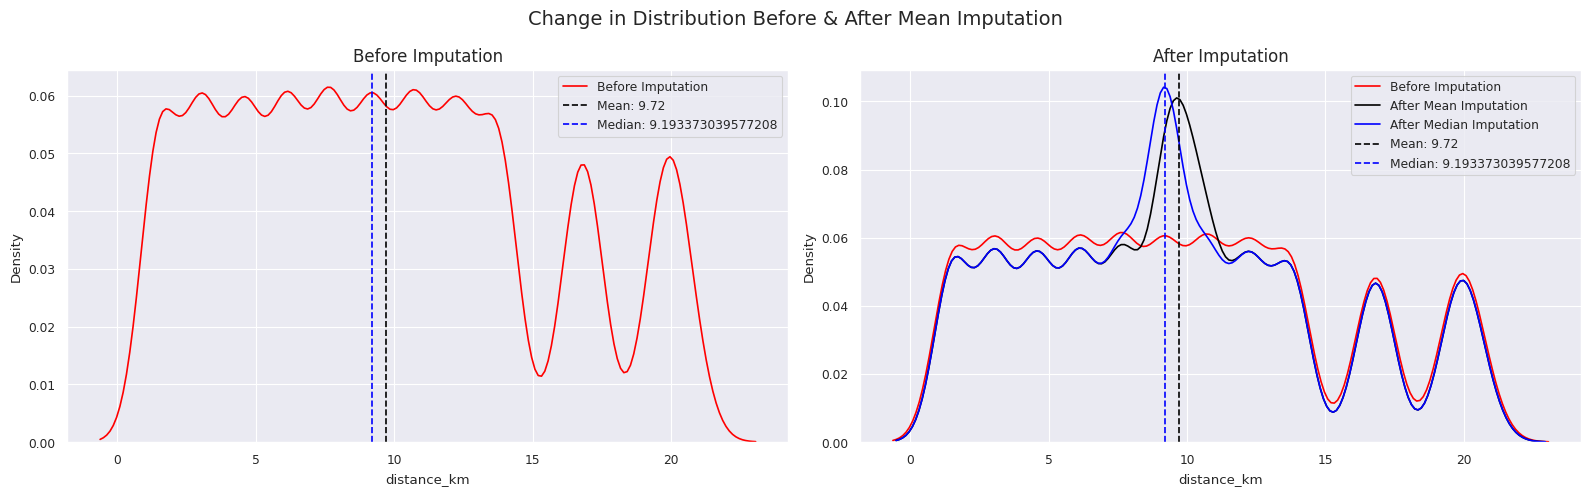

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,distance_km,0.620423,0.627451


In [43]:
check_for_imputation_type(feature_name = 'distance_km', data_type = 'numerical')

In [45]:
cleaned_df = pd.read_csv('/content/3. swiggy_data_cleaned_not_imputed.csv')

In [46]:
geospatial_df = cleaned_df[['restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'distance_km']]

geospatial_df[geospatial_df.isnull().all(axis = 1)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,distance_km
33,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,NaN,NaN,NaN
57,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
45477,NaN,NaN,NaN,NaN,NaN
45484,NaN,NaN,NaN,NaN,NaN
45485,NaN,NaN,NaN,NaN,NaN
45487,NaN,NaN,NaN,NaN,NaN


In [47]:
geospatial_df[geospatial_df.isnull().any(axis = 1)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,distance_km
33,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,NaN,NaN,NaN
57,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
45477,NaN,NaN,NaN,NaN,NaN
45484,NaN,NaN,NaN,NaN,NaN
45485,NaN,NaN,NaN,NaN,NaN
45487,NaN,NaN,NaN,NaN,NaN


In [48]:
geospatial_df['distance_km'].isnull().sum()

np.int64(3630)

Observations

---
- `distance_km` is a **continuous numerical feature**.

- Approximately `7.84%` of the values in `distance_km` are missing in the dataset used for the missingness analysis.

- From the distribution analysis, replacing all missing values with the mean or median creates an **artificial concentration around the central region** of the distribution.

- Therefore, although mean and median imputation are simple approaches, they noticeably modify the original distribution of `distance_km`.

- The missingness indicator of `distance_km` shows approximately **zero Pearson and Spearman nullity correlation** with the other missingness indicators considered in the nullity-correlation analysis.

- This means that we did not detect a strong pairwise co-missingness relationship between `distance_km` and those particular features.

- However, approximately zero nullity correlation does **not prove independence or MCAR**. It only means that strong pairwise association between those missingness indicators was not detected.

- In the missingness-prediction experiment, the results were approximately:
  - Train Macro-F1: `0.61`
  - Test  Macro-F1: `0.61`

- These results show substantially less missingness predictability than the results obtained for features such as `rider_age`, `rider_ratings`, and `order_pickup_time_mins`.

- Therefore, the experiment provides only **limited / weak MAR-like evidence** that the occurrence of missingness in `distance_km` can be explained by the observed predictors used in the experiment.

- However, `distance_km` is different from many of the other numerical features because it was not originally measured independently. It was **derived using the Haversine distance formula** from:
  - `restaurant_latitude`
  - `restaurant_longitude`
  - `delivery_latitude`
  - `delivery_longitude`

- The Haversine calculation requires all four coordinate values. Therefore, if the required latitude or longitude information is unavailable, `distance_km` cannot be calculated and consequently becomes `NaN`.

- The geospatial inspection shows that the missingness of `distance_km` is directly connected to missingness in its source coordinate variables.

- So, the missing values in `distance_km` are not appearing randomly without any reason. They are happening because the coordinate values that are used to calculate `distance_km` are themselves missing.

- For example: If `restaurant_latitude = NaN`, then: `distance_km = NaN` because we do not have all the required information needed to calculate the distance.

- The missingness in `distance_km` depends on its own missing values, there is a reason related to the missing values that explain why they are missing, which means **MNAR-like Evidence**

- Therefore, we should call missingness in `distance_km` to be **MNAR-like evidence** rather than saying definitely MNAR, because we does not mathematically prove it.

- For example, if very long delivery distances were systematically more likely to have their coordinates hidden or unrecorded specifically because the true distance was large, that could provide MNAR-like evidence.

- It is also important to distinguish between:
  - **Missingness modeling:** Why is `distance_km` unavailable?
  - **Value imputation:** Given that `distance_km` is unavailable, what is its likely true value?

- Knowing why `distance_km` becomes `NaN` does not automatically tell us which method will most accurately estimate its missing values.

- Since `distance_km` is deterministically derived from the coordinate variables, the conceptually cleanest solution would be to **recover/impute the required coordinates and then recompute `distance_km` using the Haversine formula**, if reliable coordinate imputation is possible.

- However, geographic coordinates should not be imputed casually. Artificially estimating latitude and longitude can create unrealistic locations and therefore unrealistic distances.

- If reliable reconstruction of the coordinates is not possible, `distance_km` can instead be treated as a numerical feature whose missing values need to be estimated directly.

- In that case, reasonable candidate strategies include:
  - `IterativeImputer`
  - `KNNImputer`

- The suitability of `IterativeImputer` or `KNNImputer` depends on whether the other available numerical features contain useful information for estimating the **actual distance values**, not on whether they explain the missingness pattern.

- If multivariate imputation is evaluated, all relevant numerical predictors can be considered rather than selecting predictors only from nullity correlations.

- Candidate approaches can also be evaluated **with and without a missing indicator**. The indicator may preserve information about the fact that the original coordinate information was unavailable, but whether this improves the downstream model should be determined empirically.

- The final imputation strategy should therefore be selected using **cross-validated downstream model performance**, comparing metrics such as R² and MAE rather than selecting an imputation method solely from the missingness mechanism.

In [49]:
X_train.drop(columns = ['restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude'], inplace = True)
X_test.drop(columns =  ['restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude'], inplace = True)

1. We remove the raw geospatial coordinates because we have already calculate `haversine distance` feature between the two coordinate points. This distance feature directly captures the spatial separation between the two locations, which may be more useful for predictive modeling than using raw latitude and longitude values separately.

2. Raw latitude and longitude values can be difficult to impute accurately
when missing, because coordinates are continuous, location-specific, and
geographically constrained.

3. Although advanced methods such as KNN Imputer and Iterative Imputer can estimate missing latitude/longitude, because they treat coordinates like normal numerical columns.

4. But the problem is: latitude and longitude are not just normal numbers.
They represent real physical locations on Earth. **So an imputer may create values that are mathematically reasonable but geographically unrealistic value.** This may generate unrealistic locations & introduce unwanted bias

5. Haversine Distance is a more robust derived feature that can be imputed using standard techniques & since the haversine distance feature is already retained. Therefore, the raw coordinates are not required for the current modeling objective

6. So we drop the original geospatial coordinate columns to reduce dimensionality, to avoid unreliable imputation and to simplify the feature set.

7. Also our modeling objective focuses on delivery duration rather than spatial dynamics, haversine distance provides sufficient spatial representation.

### f. order_placed_hr

,feature,data_type,missing_count,missing_%
0,order_placed_hr,float64,47,0.13




 Unique Value: [0.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, nan]



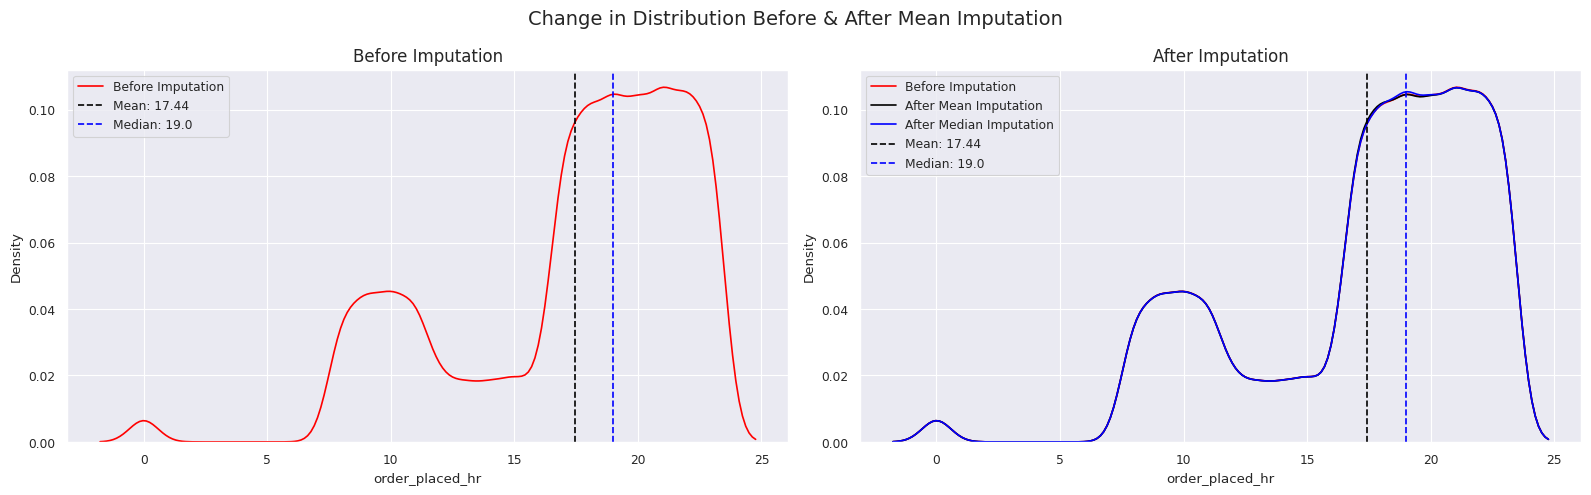

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,order_placed_hr,0.517859,0.499725


In [50]:
check_for_imputation_type(feature_name = 'order_placed_hr' , data_type = 'numerical')

## 2.Categorical & Boolean features

### a. order_day_of_week

- `SimpleImputer(strategy = 'most_frequent')`

,feature,data_type,missing_count,missing_%
0,order_day_of_week,object,47,0.13




 Unique Value: ['Saturday', 'Friday', 'Monday', 'Sunday', 'Tuesday', 'Wednesday', 'Thursday', nan]



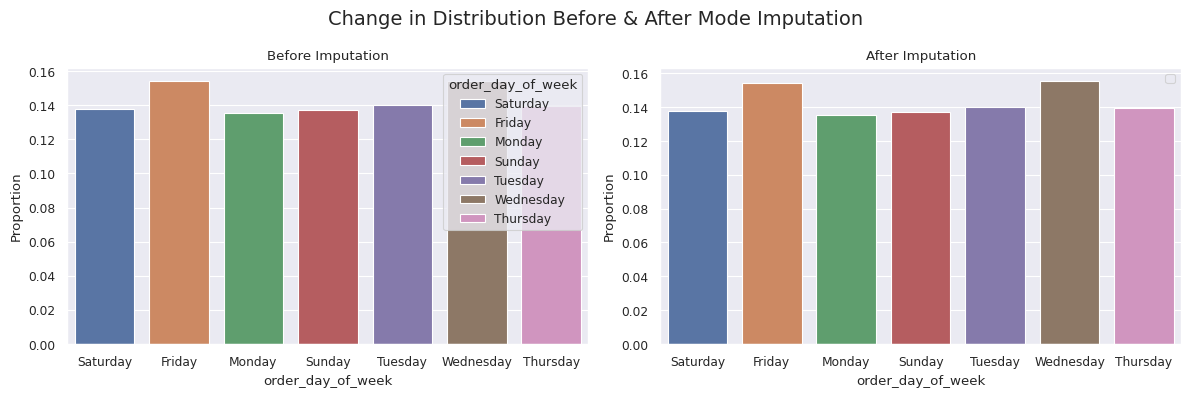

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro


In [51]:
check_for_imputation_type(feature_name = 'order_day_of_week', data_type = 'categorical')

### b. weather

1. `Simple Imputer(strategy = 'most_frequent')`

,feature,data_type,missing_count,missing_%
0,weather,object,417,1.15




 Unique Value: ['Cloudy', 'Fog', 'Stormy', 'Sandstorms', 'Windy', 'Sunny', nan]



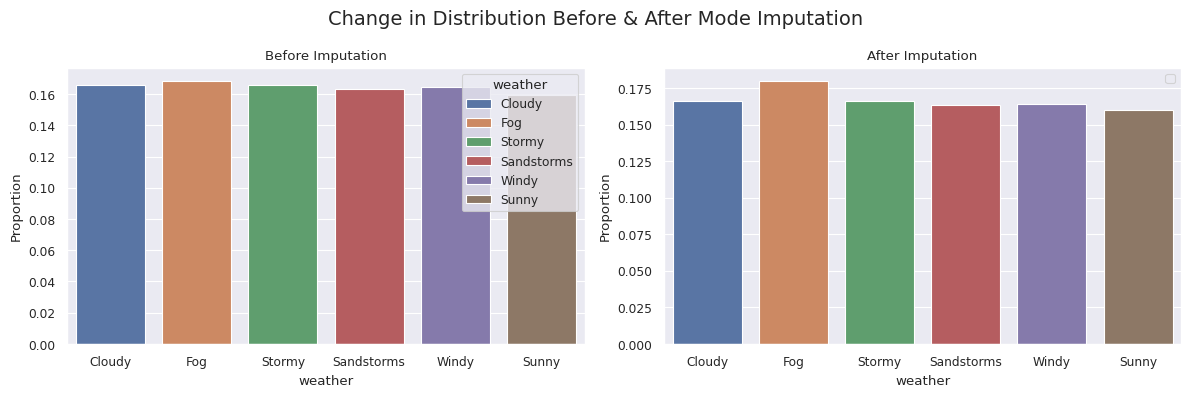

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,weather,0.950036,0.948424


In [52]:
check_for_imputation_type(feature_name = 'weather', data_type = 'categorical')

### c. traffic

1. `Simple Imputer(strategy = 'most_frequent')`

,feature,data_type,missing_count,missing_%
0,traffic,object,403,1.11




 Unique Value: ['High', 'Jam', 'Medium', 'Low', nan]



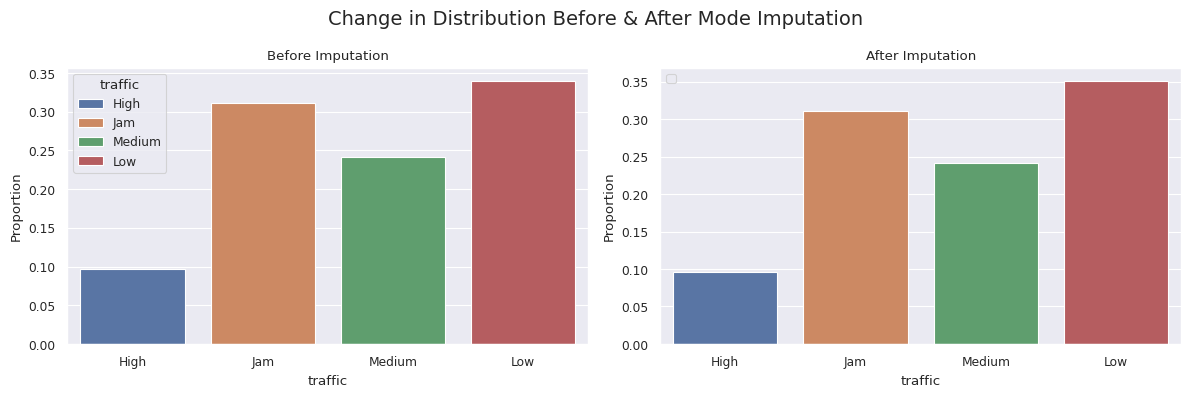

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,traffic,0.957338,0.944389


In [53]:
check_for_imputation_type(feature_name = 'traffic', data_type = 'categorical')

### d. `is_festival`

1. `Simple Imputer(strategy = 'most_frequent')`

,feature,data_type,missing_count,missing_%
0,is_festival,boolean,182,0.5




 Unique Value: [False, True, <NA>]



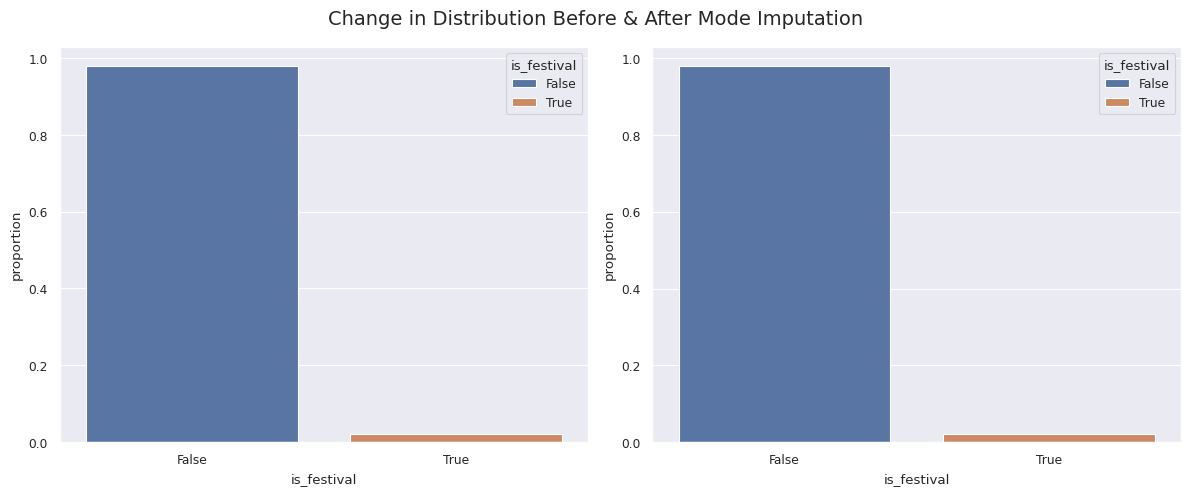

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro
0,is_festival,0.49874,0.498705


In [54]:
check_for_imputation_type(feature_name = 'is_festival', data_type = 'boolean')

### e. is_friday_night

`Simple Imputer(strategy = 'most_frequent')`

,feature,data_type,missing_count,missing_%
0,is_friday_night,boolean,47,0.13




 Unique Value: [False, True, <NA>]



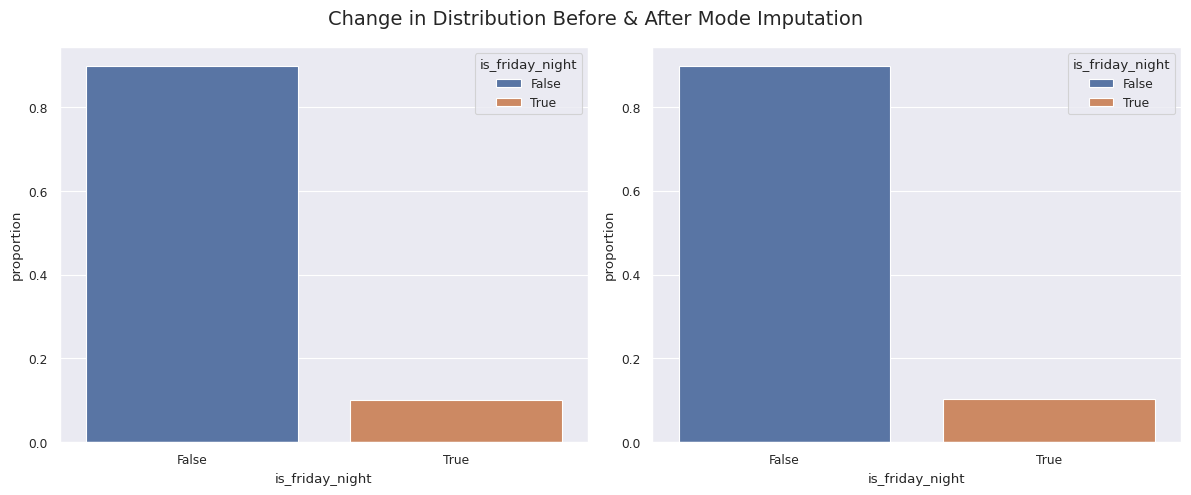

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro


In [55]:
check_for_imputation_type(feature_name = 'is_friday_night', data_type = 'boolean')

 ### f. `is_weekend`

 `Simple Imputer(strategy = 'most_frequent')`

,feature,data_type,missing_count,missing_%
0,is_weekend,boolean,47,0.13




 Unique Value: [True, False, <NA>]



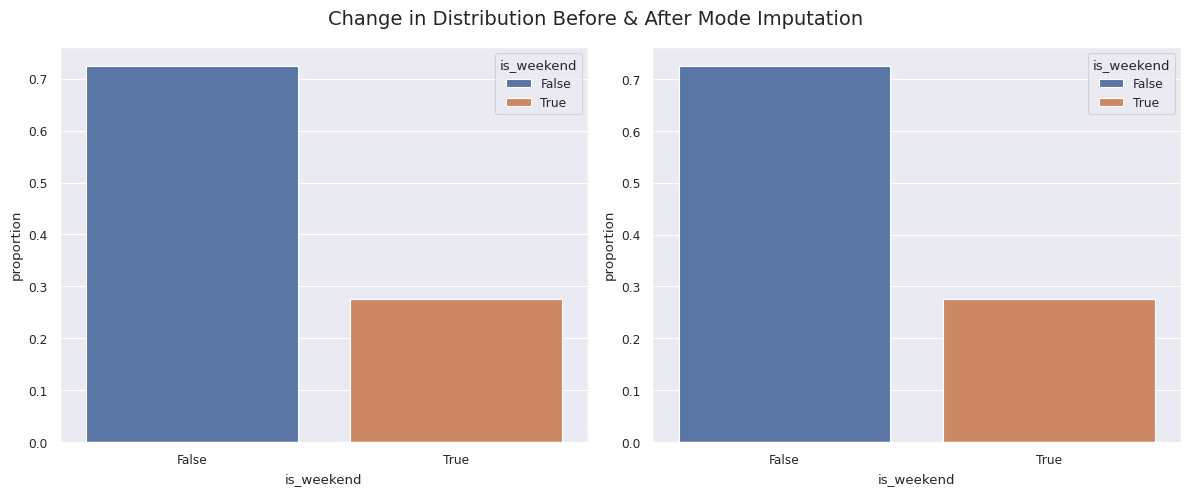

,Nullity features,Train_F1_macro(avg),Test(Unseen)_F1_macro


In [56]:
check_for_imputation_type(feature_name = 'is_weekend', data_type = 'boolean')

# Imputation Strategy decision making

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer, MissingIndicator

In [58]:
X_train.drop(columns = ['city_name'], inplace = True)
X_test.drop(columns = ['city_name'], inplace = True)

In [59]:
boolean_cols = X_train.select_dtypes(include = 'boolean').columns.tolist()

for col in boolean_cols:
    X_train[col] = X_train[col].astype(float)

In [60]:
get_missing_info(X_train)

,feature,data_type,missing_count,missing_%
0,rider_age,float64,1502,4.13
1,rider_ratings,float64,1541,4.23
2,multiple_deliveries,float64,808,2.22
3,vehicle_type,object,0,0.00
4,vehicle_condition,object,0,0.00
5,distance_km,float64,2854,7.84
6,order_type,object,0,0.00
7,order_pickup_time_mins,float64,1319,3.62
8,order_placed_hr,float64,47,0.13
9,sin_hr,float64,47,0.13


In [61]:
mask = X_train.isnull().sum()
nullity_cols = mask[mask>0].index.tolist()
nullity_cols

['rider_age',
 'rider_ratings',
 'multiple_deliveries',
 'distance_km',
 'order_pickup_time_mins',
 'order_placed_hr',
 'sin_hr',
 'cos_hr',
 'order_day',
 'order_day_of_week',
 'is_friday_night',
 'is_weekend',
 'is_festival',
 'weather',
 'traffic']

In [62]:
non_nullity_cols = mask[mask==0].index.tolist()
non_nullity_cols

['vehicle_type',
 'vehicle_condition',
 'order_type',
 'order_time_of_day',
 'is_lunch_rush',
 'is_dinner_rush',
 'order_month',
 'is_month_start',
 'is_month_end']

## a. Pipeline-1

In [84]:
impute_numerical_cols = ['rider_age', 'rider_ratings', 'multiple_deliveries', 'distance_km', 'order_pickup_time_mins',
                         'order_placed_hr', 'sin_hr', 'cos_hr', 'order_day']

iterative_imputer = IterativeImputer(estimator = RandomForestRegressor(n_estimators = 50, random_state = 42), max_iter = 10, random_state = 42)


# For `order_day_of_week` & `weather`
pipe_impute_encode_ohe_cat = Pipeline(steps = [
                                          ('imputation', SimpleImputer(strategy = 'most_frequent')),
                                          ('encoding', OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore'))
                                          ])

# For traffic
pipe_impute_encode_traffic = Pipeline(steps = [
                                     ('imputation', SimpleImputer(strategy = 'most_frequent')),
                                     ('encoding', OrdinalEncoder(categories = [['Low','Medium', 'High', 'Jam']], dtype = int,
                                                                 handle_unknown = 'use_encoded_value', unknown_value = -9999))
                                     ])

# ------------------------------------------------------------- Applied Transformations----------------------------------------------------------------------------

vehicle_condition_ordinal_encoder = OrdinalEncoder(categories = [['3','2','1','0']], dtype = int, handle_unknown = 'use_encoded_value', unknown_value = -9999)
remaining_ohe_encoder = OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore')

trf_applied = [('Impute_Numerical', iterative_imputer, impute_numerical_cols),
               ('Impute_Boolean', SimpleImputer(strategy = 'most_frequent'), ['is_friday_night', 'is_weekend', 'is_festival']),
               ('Impute_then_Encode_Nominal', pipe_impute_encode_ohe_cat, ['order_day_of_week', 'weather']),
               ('Impute_then_Encode_traffic', pipe_impute_encode_traffic, ['traffic']),
               ('Encode_vehicle_condition', vehicle_condition_ordinal_encoder, ['vehicle_condition']),
               ('Encode_Remaining_Nominal', remaining_ohe_encoder , ['vehicle_type', 'order_type', 'order_time_of_day']) ]

preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'passthrough')

# --------------------------------------Final Model Building--------------------------------------
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1))
])

model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Impute_Numerical',
                                                  IterativeImputer(estimator=RandomForestRegressor(n_estimators=50,
                                                                                                   random_state=42),
                                                                   random_state=42),
                                                  ['rider_age', 'rider_ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_pickup_time_mins',
                                                   'order_placed_hr', 'sin_hr',
                                                   'cos_hr', 'order_day']...
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition']),
                                                 ('Encode_Remaining_Nominal',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'order_type',
                                                   'order_time_of_day'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [85]:
model_pipe.score(X_train, y_train)

0.9749218941836528

In [86]:
model_pipe.score(X_test, y_test)

0.8189394663416414

## b. Pipeline-2

In [63]:
impute_numerical_cols = ['rider_age', 'rider_ratings', 'multiple_deliveries', 'distance_km', 'order_pickup_time_mins',
                         'order_placed_hr', 'sin_hr', 'cos_hr', 'order_day']

iterative_imputer = IterativeImputer(estimator = RandomForestRegressor(n_estimators = 30, random_state = 42), max_iter = 10, add_indicator = True, random_state = 42)

# For `order_day_of_week` & `weather`
pipe_impute_encode_ohe_cat = Pipeline(steps = [
                                      ('imputation', SimpleImputer(strategy = 'most_frequent', add_indicator = True)),
                                      ('encoding', OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore'))
                                      ])

# For traffic
pipe_impute_encode_traffic = Pipeline(steps = [
                                     ('imputation', SimpleImputer(strategy = 'most_frequent')),
                                     ('encoding', OrdinalEncoder(categories = [['Low','Medium', 'High', 'Jam']], dtype = int,
                                                                 handle_unknown = 'use_encoded_value', unknown_value = -9999))
                                     ])

# ------------------------------------------------------------- Applied Transformations----------------------------------------------------------------------------

vehicle_condition_ordinal_encoder = OrdinalEncoder(categories = [['3','2','1','0']], dtype = int, handle_unknown = 'use_encoded_value', unknown_value = -9999)
remaining_ohe_encoder = OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore')

trf_applied = [('Impute_Numerical', iterative_imputer, impute_numerical_cols),
               ('Impute_Boolean', SimpleImputer(strategy = 'most_frequent'), ['is_friday_night', 'is_weekend', 'is_festival']),
               ('Impute_then_Encode_Nominal', pipe_impute_encode_ohe_cat, ['order_day_of_week', 'weather']),
               ('Missing_Indicator_traffic', MissingIndicator(), ['traffic']),
               ('Impute_then_Encode_traffic', pipe_impute_encode_traffic, ['traffic']),
               ('Encode_vehicle_condition', vehicle_condition_ordinal_encoder, ['vehicle_condition']),
               ('Encode_Remaining_Nominal', remaining_ohe_encoder , ['vehicle_type', 'order_type', 'order_time_of_day']) ]

preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'passthrough')

# --------------------------------------Final Model Building--------------------------------------
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1))
])

model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Impute_Numerical',
                                                  IterativeImputer(add_indicator=True,
                                                                   estimator=RandomForestRegressor(n_estimators=30,
                                                                                                   random_state=42),
                                                                   random_state=42),
                                                  ['rider_age', 'rider_ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_pickup_time_mins',
                                                   'order_placed_hr', 'sin_hr',
                                                   'c...
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition']),
                                                 ('Encode_Remaining_Nominal',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'order_type',
                                                   'order_time_of_day'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [66]:
model_pipe.score(X_train, y_train)

0.975228383187008

In [67]:
model_pipe.score(X_test, y_test) # adding missingness as predictor doesn't contribute into increase in model performace

0.8200327473413354

## c. Pipeline-3

In [68]:
impute_numerical_cols = ['rider_age', 'rider_ratings', 'multiple_deliveries', 'distance_km', 'order_pickup_time_mins',
                         'order_placed_hr', 'sin_hr', 'cos_hr', 'order_day']


# For `order_day_of_week` & `weather`
pipe_impute_encode_ohe_cat = Pipeline(steps = [
                                      ('imputation', SimpleImputer(strategy = 'most_frequent')),
                                      ('encoding', OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore'))
                                      ])

# For traffic
pipe_impute_encode_traffic = Pipeline(steps = [
                                     ('imputation', SimpleImputer(strategy = 'most_frequent')),
                                     ('encoding', OrdinalEncoder(categories = [['Low','Medium', 'High', 'Jam']], dtype = int,
                                                                 handle_unknown = 'use_encoded_value', unknown_value = -9999))
                                     ])

# ------------------------------------------------------------- Applied Transformations----------------------------------------------------------------------------

vehicle_condition_ordinal_encoder = OrdinalEncoder(categories = [['3','2','1','0']], dtype = int, handle_unknown = 'use_encoded_value', unknown_value = -9999)
remaining_ohe_encoder = OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore')

trf_applied = [('Impute_Numerical', KNNImputer(n_neighbors = 3, weights = 'distance'), impute_numerical_cols),
               ('Impute_Boolean', SimpleImputer(strategy = 'most_frequent'), ['is_friday_night', 'is_weekend', 'is_festival']),
               ('Impute_then_Encode_Nominal', pipe_impute_encode_ohe_cat, ['order_day_of_week', 'weather']),
               ('Impute_then_Encode_traffic', pipe_impute_encode_traffic, ['traffic']),
               ('Encode_vehicle_condition', vehicle_condition_ordinal_encoder, ['vehicle_condition']),
               ('Encode_Remaining_Nominal', remaining_ohe_encoder , ['vehicle_type', 'order_type', 'order_time_of_day']) ]

preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'passthrough', n_jobs = -1)

# --------------------------------------Final Model Pipeline --------------------------------------
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1))
])
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('Impute_Numerical',
                                                  KNNImputer(n_neighbors=3,
                                                             weights='distance'),
                                                  ['rider_age', 'rider_ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_pickup_time_mins',
                                                   'order_placed_hr', 'sin_hr',
                                                   'cos_hr', 'order_day']),
                                                 ('Impute_Boolean',
                                                  SimpleImputer(strategy='...
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition']),
                                                 ('Encode_Remaining_Nominal',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'order_type',
                                                   'order_time_of_day'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [69]:
model_pipe.score(X_train, y_train)

0.9728813344793192

In [70]:
model_pipe.score(X_test, y_test)

0.8011267324791479

# Final Selected Pipeline

In [72]:
def missing_value_imputation(training_data, test_data):

    impute_numerical_cols = ['rider_age', 'rider_ratings', 'multiple_deliveries', 'distance_km', 'order_pickup_time_mins',
                            'order_placed_hr', 'sin_hr', 'cos_hr', 'order_day']

    # ------------------------------------------------------------- Applied Transformations----------------------------------------------------------------------------
    trf_applied = [('Impute_Numerical', KNNImputer(n_neighbors = 3, weights = 'distance'), impute_numerical_cols),
                   ('Impute_Boolean', SimpleImputer(strategy = 'most_frequent'), ['is_friday_night', 'is_weekend', 'is_festival']),
                   ('Impute_Nominal', SimpleImputer(strategy = 'most_frequent'), ['order_day_of_week', 'weather', 'traffic'])]

    preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'passthrough', n_jobs = -1)
    preprocessing.set_output(transform = 'pandas')

    # Transformation
    training_data = preprocessing.fit_transform(training_data)
    test_data = preprocessing.transform(test_data)

    # Extracting Original column names
    cols_name = pd.Series(training_data.isnull().columns).str.split('__').str.get(1).values

    # Replacing original columns names
    training_data.columns = cols_name
    test_data.columns = cols_name

    training_data['sin_hr'] = np.sin((np.pi * training_data['order_placed_hr'])/12)
    training_data['cos_hr'] = np.cos((np.pi * training_data['order_placed_hr'])/12)

    test_data['sin_hr'] = np.sin((np.pi * test_data['order_placed_hr'])/12)
    test_data['cos_hr'] = np.cos((np.pi * test_data['order_placed_hr'])/12)

    return training_data, test_data

In [73]:
X_train_trf, X_test_trf = missing_value_imputation(training_data = X_train, test_data = X_test)

$$sin^2(\theta) + cos^2(\theta) = 1 $$

In [74]:
l = (X_train_trf['sin_hr']**2 + X_train_trf['cos_hr']**2).sum()

l == len(X_train) # logic is Working fine

np.True_

In [75]:
m = (X_test_trf['sin_hr']**2 + X_test_trf['cos_hr']**2).sum()

m == len(X_test) # Logic is Working fine

np.True_

# Correcting Data-Types

In [76]:
integer_cols = ['rider_age', 'multiple_deliveries', 'order_pickup_time_mins', 'order_placed_hr', 'order_day', 'order_month',
                'is_friday_night', 'is_weekend', 'is_festival', 'is_lunch_rush', 'is_dinner_rush', 'is_month_start', 'is_month_end']

X_train_trf = X_train_trf.astype({i:int for i in integer_cols})
X_test_trf= X_test_trf.astype({i:int for i in integer_cols})

In [77]:
X_train_trf = X_train_trf[X_train.columns.tolist()]
X_test_trf = X_test_trf[X_test.columns.tolist()]

In [78]:
t1 = get_missing_info(X_train)
t2 = get_missing_info(X_train_trf)

pd.concat([t1, t2], axis = 1)

,feature,data_type,missing_count,missing_%,feature,data_type,missing_count,missing_%
0,rider_age,float64,1502,4.13,rider_age,int64,0,0.0
1,rider_ratings,float64,1541,4.23,rider_ratings,float64,0,0.0
2,multiple_deliveries,float64,808,2.22,multiple_deliveries,int64,0,0.0
3,vehicle_type,object,0,0.00,vehicle_type,object,0,0.0
4,vehicle_condition,object,0,0.00,vehicle_condition,object,0,0.0
5,distance_km,float64,2854,7.84,distance_km,float64,0,0.0
6,order_type,object,0,0.00,order_type,object,0,0.0
7,order_pickup_time_mins,float64,1319,3.62,order_pickup_time_mins,int64,0,0.0
8,order_placed_hr,float64,47,0.13,order_placed_hr,int64,0,0.0
9,sin_hr,float64,47,0.13,sin_hr,float64,0,0.0


In [79]:
t1 = get_missing_info(X_test)
t2 = get_missing_info(X_test_trf)

pd.concat([t1, t2], axis = 1)

,feature,data_type,missing_count,missing_%,feature,data_type,missing_count,missing_%
0,rider_age,float64,351,3.86,rider_age,int64,0,0.0
1,rider_ratings,float64,366,4.02,rider_ratings,float64,0,0.0
2,multiple_deliveries,float64,185,2.03,multiple_deliveries,int64,0,0.0
3,vehicle_type,object,0,0.00,vehicle_type,object,0,0.0
4,vehicle_condition,object,0,0.00,vehicle_condition,object,0,0.0
5,distance_km,float64,776,8.53,distance_km,float64,0,0.0
6,order_type,object,0,0.00,order_type,object,0,0.0
7,order_pickup_time_mins,float64,320,3.52,order_pickup_time_mins,int64,0,0.0
8,order_placed_hr,float64,9,0.10,order_placed_hr,int64,0,0.0
9,sin_hr,float64,9,0.10,sin_hr,float64,0,0.0


# Check Change in Distribution

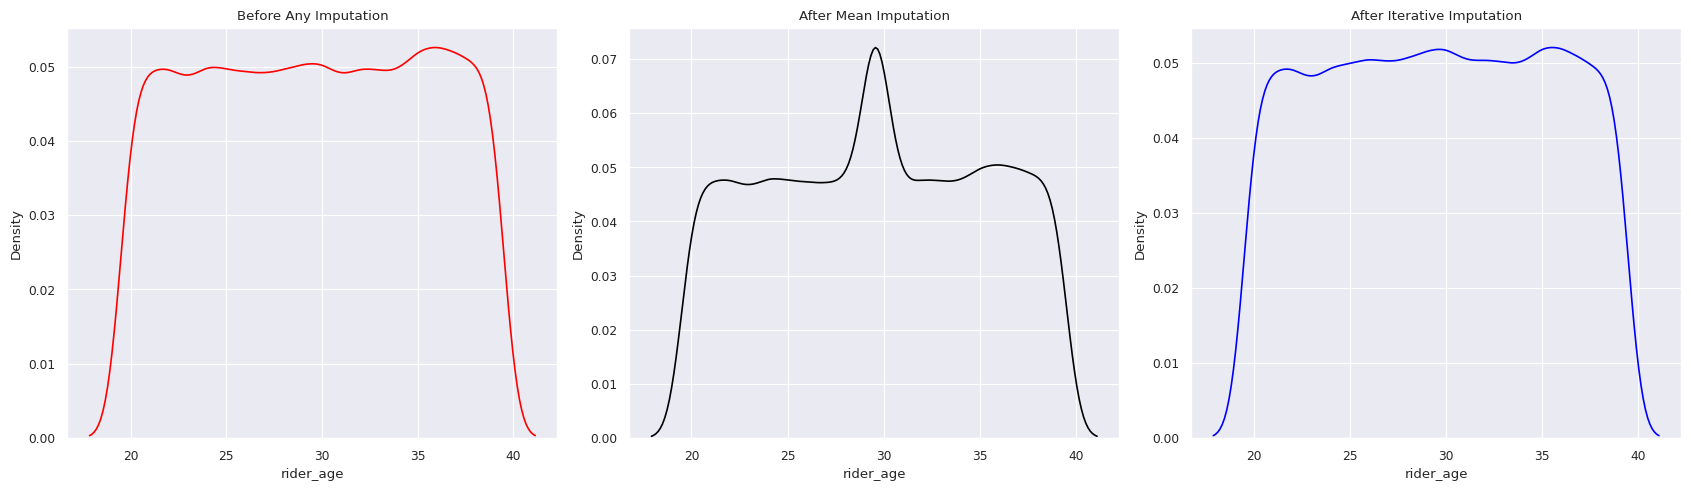

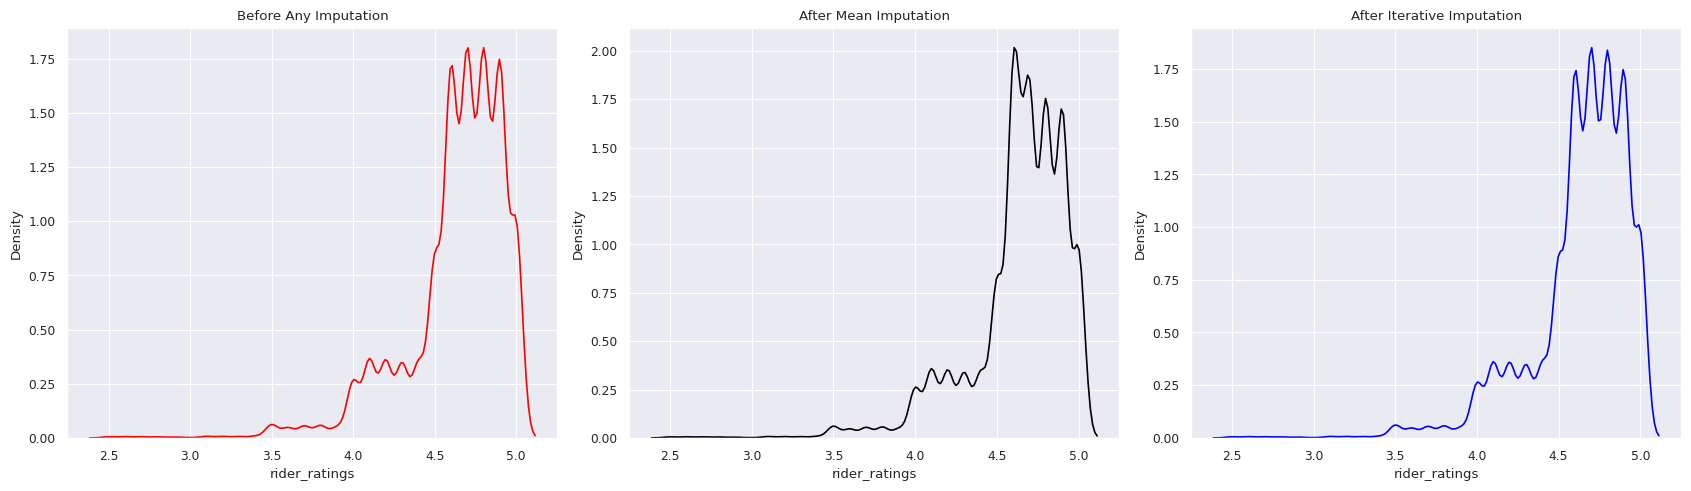

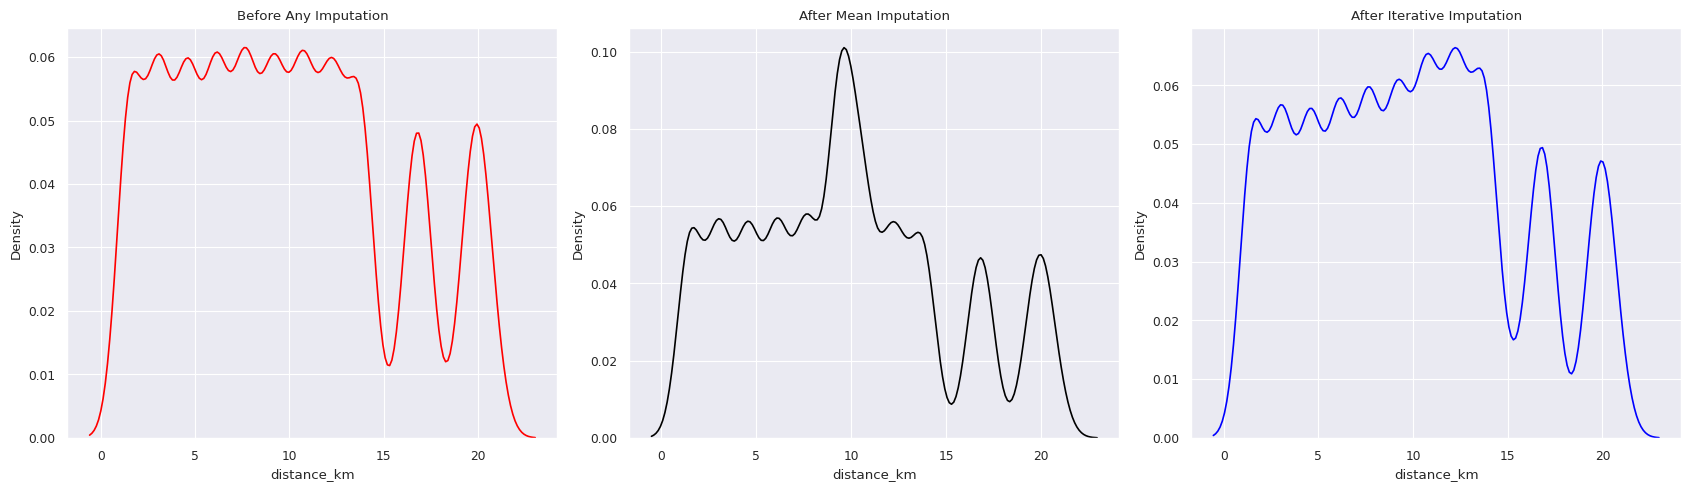

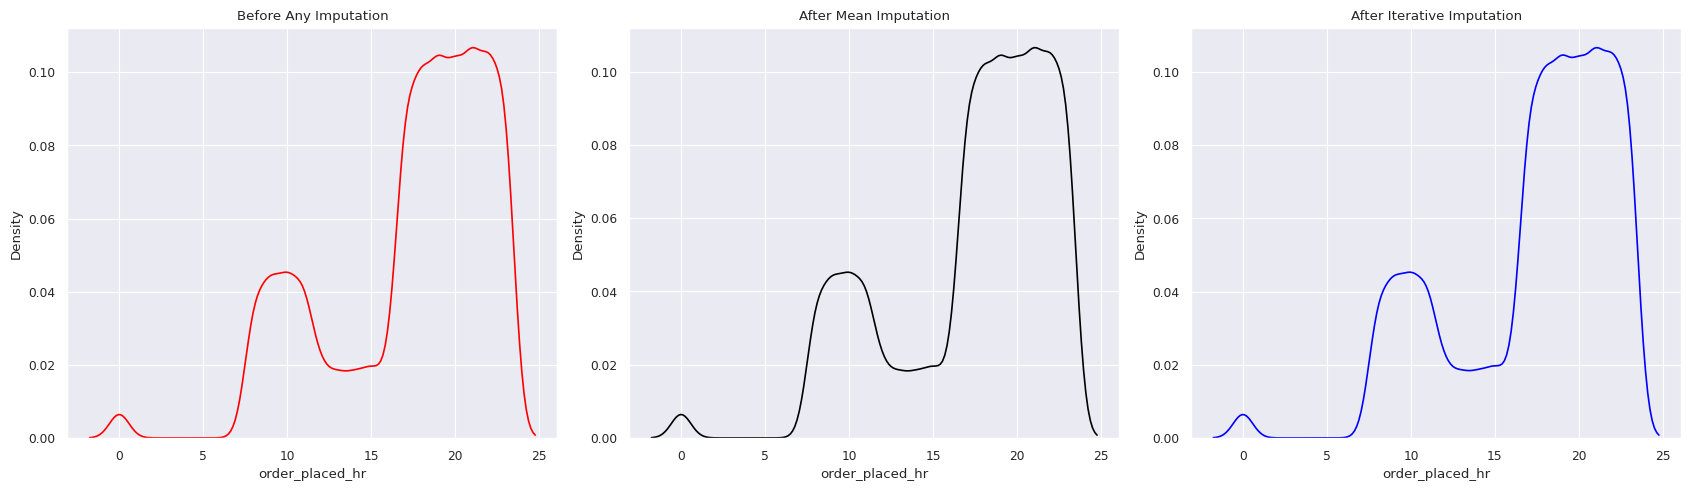

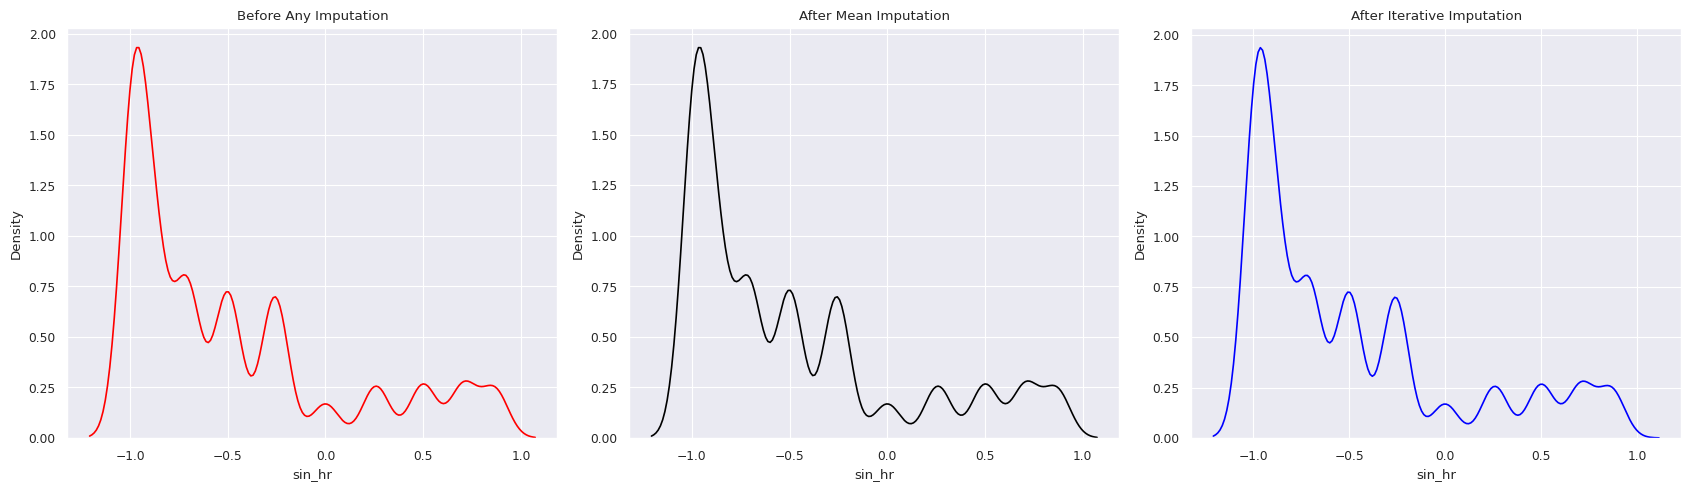

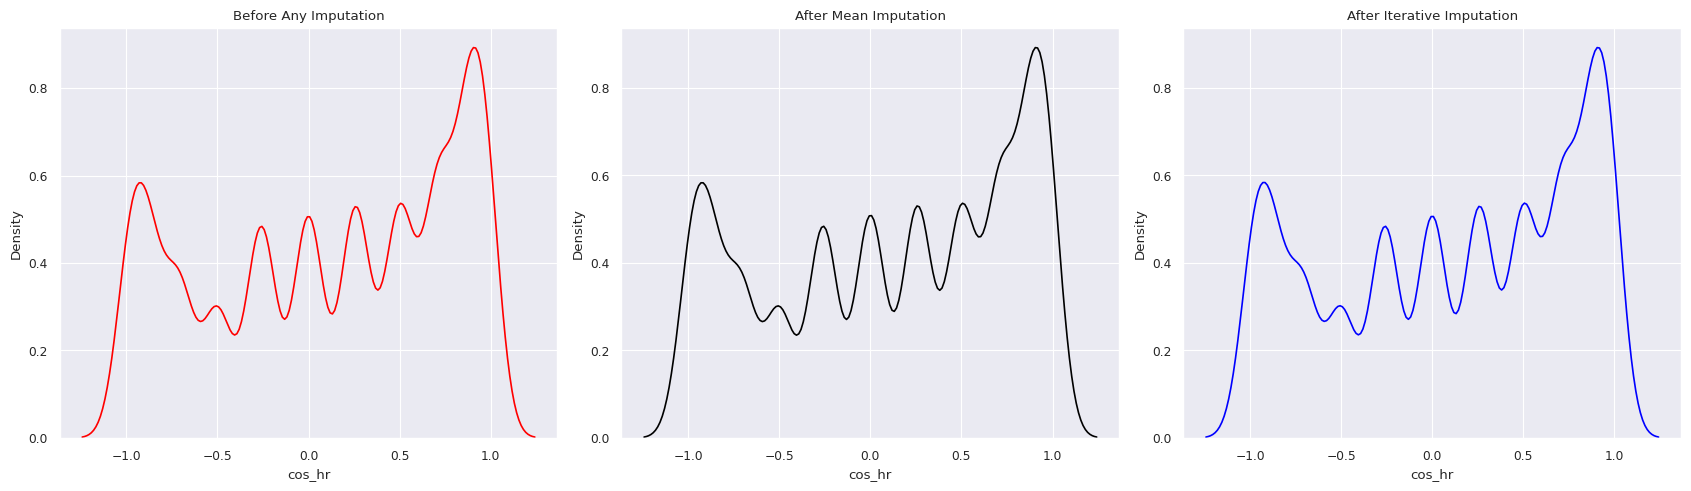

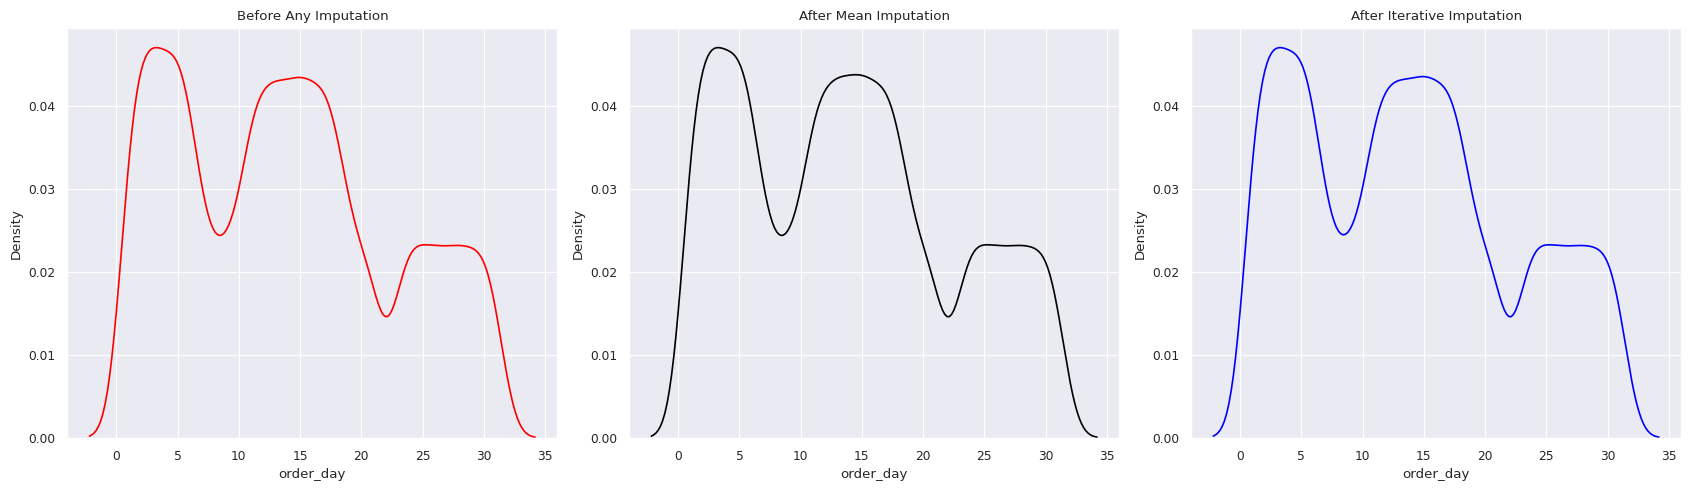

In [80]:
for i in ['rider_age', 'rider_ratings', 'distance_km', 'order_placed_hr', 'sin_hr', 'cos_hr', 'order_day']:

    fig, (ax_before, ax_mean, ax_iterative) = plt.subplots(nrows = 1, ncols = 3, figsize = (17,5))

    # Before Imputation
    sns.kdeplot(data = X_train[i], ax = ax_before, color = 'red')
    ax_before.set_title('Before Any Imputation')

    # After Mean Imputation
    mean = X_train[i].mean()
    sns.kdeplot(data = X_train[i].fillna(mean), ax = ax_mean, color = 'black')
    ax_mean.set_title('After Mean Imputation')

    # After Iterative Imputation
    sns.kdeplot(data = X_train_trf[i], ax = ax_iterative, color = 'blue')
    ax_iterative.set_title('After Iterative Imputation')

    # Improve Spacing & layout
    plt.tight_layout()
    plt.show()

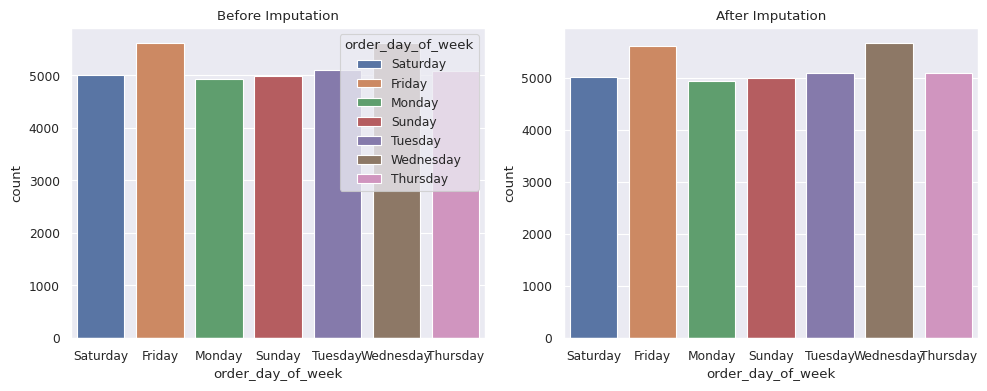

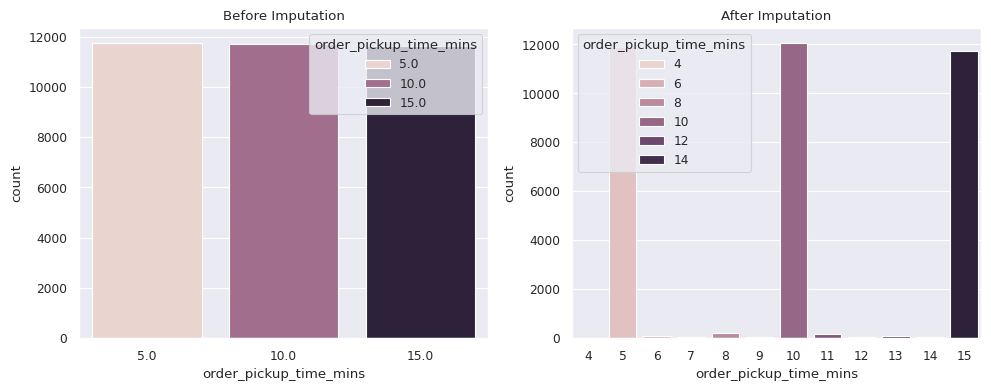

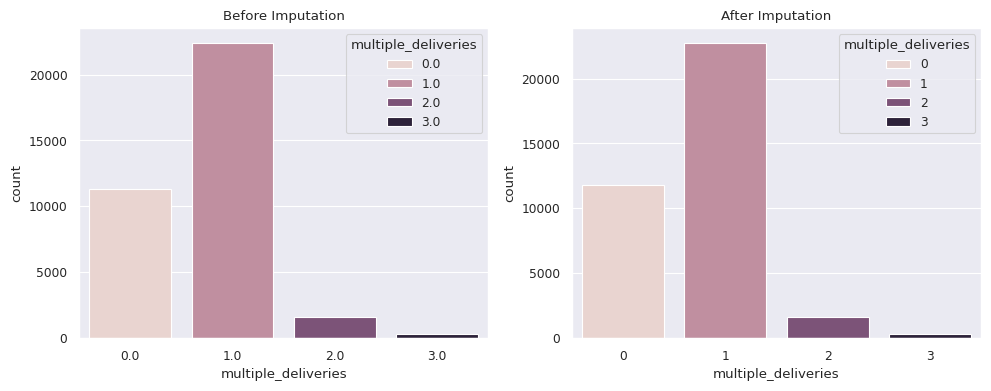

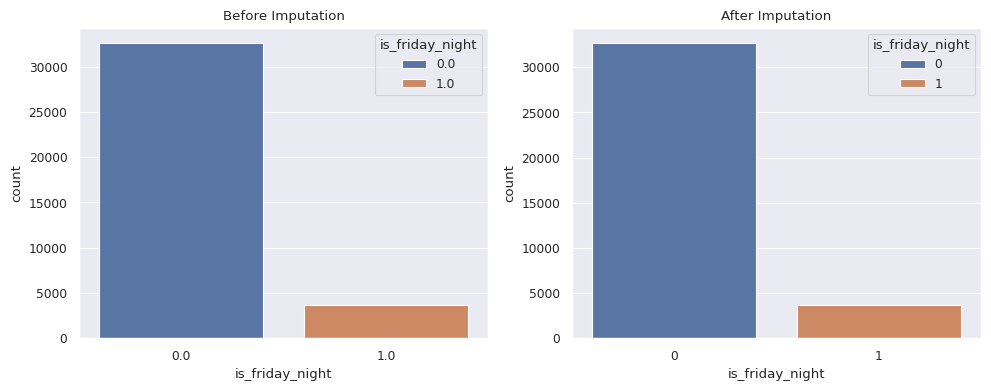

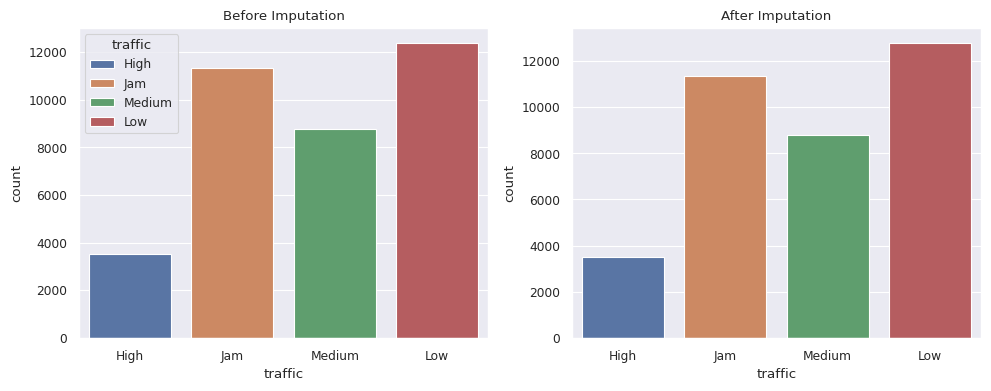

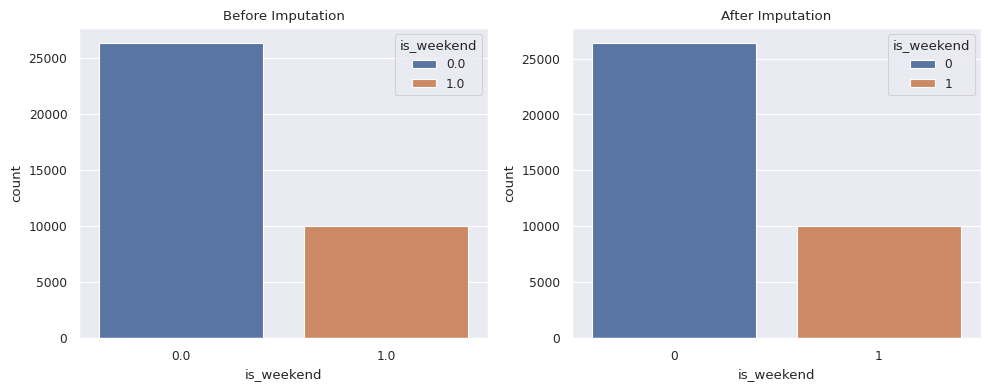

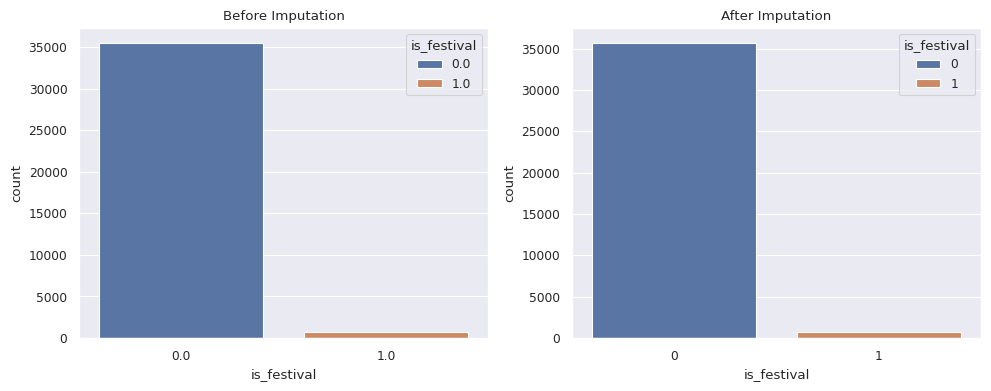

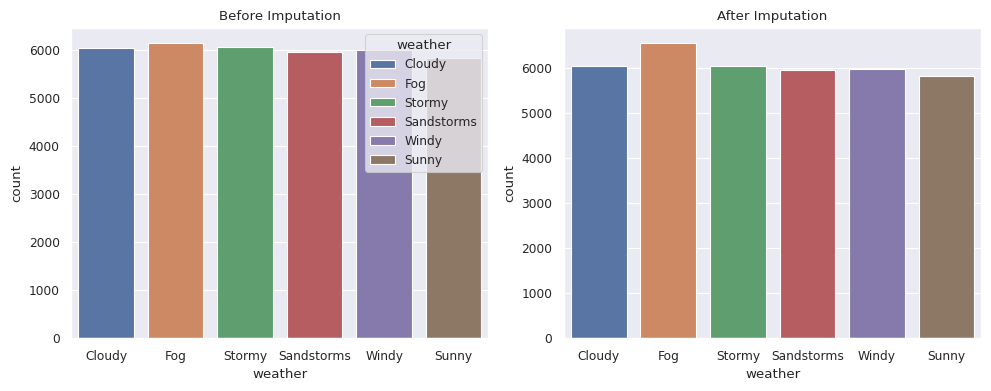

In [81]:
for i in ['order_day_of_week', 'order_pickup_time_mins', 'multiple_deliveries', 'is_friday_night', 'traffic', 'is_weekend', 'is_festival', 'weather']:

    # Before Imputation

    fig, (ax_before, ax_after) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
    sns.countplot(data = X_train, x = i, hue = i, ax = ax_before)
    ax_before.set_title('Before Imputation')

    # After Imputation
    sns.countplot(data = X_train_trf, x = i, hue = i, ax = ax_after)
    ax_after.set_title('After Imputation')

    plt.tight_layout()
    plt.show()

# Export Imputed Train & Test Data

In [82]:
imputed_training_data = pd.concat([X_train_trf, y_train], axis = 1).reset_index(drop = True)
imputed_test_data = pd.concat([X_test_trf, y_test], axis = 1).reset_index(drop = True)

In [83]:
t1 = get_missing_info(imputed_training_data)
t2 = get_missing_info(imputed_test_data)

pd.concat([t1, t2], axis = 1)

,feature,data_type,missing_count,missing_%,feature,data_type,missing_count,missing_%
0,rider_age,int64,0,0.0,rider_age,int64,0,0.0
1,rider_ratings,float64,0,0.0,rider_ratings,float64,0,0.0
2,multiple_deliveries,int64,0,0.0,multiple_deliveries,int64,0,0.0
3,vehicle_type,object,0,0.0,vehicle_type,object,0,0.0
4,vehicle_condition,object,0,0.0,vehicle_condition,object,0,0.0
5,distance_km,float64,0,0.0,distance_km,float64,0,0.0
6,order_type,object,0,0.0,order_type,object,0,0.0
7,order_pickup_time_mins,int64,0,0.0,order_pickup_time_mins,int64,0,0.0
8,order_placed_hr,int64,0,0.0,order_placed_hr,int64,0,0.0
9,sin_hr,float64,0,0.0,sin_hr,float64,0,0.0


In [84]:
imputed_training_data.head()

,rider_age,rider_ratings,multiple_deliveries,vehicle_type,vehicle_condition,distance_km,order_type,order_pickup_time_mins,order_placed_hr,sin_hr,cos_hr,order_time_of_day,is_lunch_rush,is_dinner_rush,order_day,order_day_of_week,is_friday_night,is_weekend,order_month,is_month_start,is_month_end,is_festival,weather,traffic,time_taken
0,32,4.6,1,Scooter,1,6.210138,Snack,15,13,-0.258819,-0.965926,Afternoon,1,0,26,Saturday,0,1,3,0,0,0,Cloudy,High,30
1,22,4.8,1,Motor-Cycle,0,4.610365,Buffet,10,21,-0.707107,0.707107,Night,0,1,11,Friday,1,0,3,0,0,0,Cloudy,Jam,26
2,33,4.7,1,Scooter,1,16.600361,Meal,15,19,-0.965926,0.258819,Evening,0,0,4,Friday,1,0,3,0,0,0,Fog,Jam,40
3,35,4.6,1,Motor-Cycle,2,20.205253,Meal,5,17,-0.965926,-0.258819,Evening,0,0,14,Monday,0,0,3,0,0,0,Cloudy,Medium,32
4,22,4.8,1,Motor-Cycle,0,19.975520,Buffet,10,20,-0.866025,0.500000,Evening,0,1,20,Sunday,0,1,3,0,0,0,Stormy,Jam,34


In [85]:
imputed_test_data.head()

,rider_age,rider_ratings,multiple_deliveries,vehicle_type,vehicle_condition,distance_km,order_type,order_pickup_time_mins,order_placed_hr,sin_hr,cos_hr,order_time_of_day,is_lunch_rush,is_dinner_rush,order_day,order_day_of_week,is_friday_night,is_weekend,order_month,is_month_start,is_month_end,is_festival,weather,traffic,time_taken
0,37,4.9,0,Motor-Cycle,2,3.025149,Snack,15,11,0.258819,-9.659258e-01,Morning,0,0,19,Saturday,0,1,3,0,0,0,Sunny,High,24
1,29,4.7,0,Motor-Cycle,1,1.552700,Snack,15,11,0.258819,-9.659258e-01,Morning,0,0,21,Monday,0,0,3,0,0,0,Sandstorms,High,16
2,34,4.5,1,Scooter,2,20.183530,Snack,5,19,-0.965926,2.588190e-01,Evening,0,0,25,Friday,1,0,3,0,0,0,Stormy,Jam,33
3,38,4.7,1,Motor-Cycle,0,7.790401,Buffet,10,18,-1.000000,-1.836970e-16,Evening,0,0,5,Tuesday,0,0,4,0,0,0,Sunny,Medium,21
4,20,4.8,1,Motor-Cycle,0,9.220882,Buffet,15,21,-0.707107,7.071068e-01,Night,0,1,1,Friday,1,0,4,1,0,0,Sandstorms,Jam,35


In [86]:
imputed_training_data.to_csv('7. swiggy_train_data_imputed.csv', index = False)

imputed_test_data.to_csv('8. swiggy_test_data_imputed.csv', index = False)

# Check baseline performace after Applying CCA vs Imputation

In [87]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PowerTransformer

## Imputed Data

In [88]:
X_train = imputed_training_data.drop(columns = ['time_taken'])
y_train = imputed_training_data['time_taken']

X_test = imputed_test_data.drop(columns = ['time_taken'])
y_test = imputed_test_data['time_taken']

In [89]:
ohe_cols = ['vehicle_type', 'order_type', 'order_time_of_day', 'order_day_of_week', 'weather']
ordinal_cols = ['vehicle_condition', 'traffic']
ordinal_categories = [['3','2','1','0'], ['Low', 'Medium', 'High', 'Jam']]

trf_applied = [('OHE', OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore'), ohe_cols),
               ('Ordinal', OrdinalEncoder(categories = ordinal_categories, dtype = int, handle_unknown = 'use_encoded_value', unknown_value = -9999), ordinal_cols)]

preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'passthrough', n_jobs = -1)

In [90]:
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1))
])

In [91]:
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'order_type',
                                                   'order_time_of_day',
                                                   'order_day_of_week',
                                                   'weather']),
                                                 ('Ordinal',
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Jam']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition',
                                                   'traffic'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [92]:
model_pipe.score(X_train, y_train)

0.9727678034541092

In [93]:
model_pipe.score(X_test, y_test)

0.8012701541475399

In [94]:
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', LinearRegression())
])

model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'order_type',
                                                   'order_time_of_day',
                                                   'order_day_of_week',
                                                   'weather']),
                                                 ('Ordinal',
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Jam']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition',
                                                   'traffic'])])),
                ('model', LinearRegression())])

In [95]:
model_pipe.score(X_train, y_train)

0.5723949633381089

In [96]:
model_pipe.score(X_test, y_test)

0.5650890873779313

# After Applying CCA

In [97]:
training_data = pd.read_csv('/content/4. swiggy_train_data_not_imputed.csv', dtype = data_types_trf)
test_data = pd.read_csv('/content/5. swiggy_test_data_not_imputed.csv', dtype = data_types_trf)

In [98]:
training_data.dropna(inplace = True)
test_data.dropna(inplace = True)

In [99]:
training_data.drop(columns = ['order_placed_datetime', 'order_picked_datetime'], inplace = True)
test_data.drop(columns = ['order_placed_datetime', 'order_picked_datetime'], inplace = True)

In [100]:
X_train = training_data.drop(columns = ['time_taken'])
y_train = training_data['time_taken']

X_test = test_data.drop(columns = ['time_taken'])
y_test = test_data['time_taken']

In [101]:
X_train.head()

,rider_age,rider_ratings,multiple_deliveries,vehicle_type,vehicle_condition,city_name,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,distance_km,order_type,order_pickup_time_mins,order_placed_hr,sin_hr,cos_hr,order_time_of_day,is_lunch_rush,is_dinner_rush,order_day,order_day_of_week,is_friday_night,is_weekend,order_month,is_month_start,is_month_end,is_festival,weather,traffic
0,32.0,4.6,1.0,Scooter,1,Chennai,12.972793,80.249982,13.012793,80.289982,6.210138,Snack,15.0,13.0,-0.2588,-0.9659,Afternoon,True,False,26.0,Saturday,False,True,3.0,False,False,False,Cloudy,High
1,22.0,4.8,1.0,Motor-Cycle,0,Hyderabad,17.431668,78.408321,17.461668,78.438321,4.610365,Buffet,10.0,21.0,-0.7071,0.7071,Night,False,True,11.0,Friday,True,False,3.0,False,False,False,Cloudy,Jam
2,33.0,4.7,1.0,Scooter,1,Ranchi,23.369746,85.339820,23.479746,85.449820,16.600361,Meal,15.0,19.0,-0.9659,0.2588,Evening,False,False,4.0,Friday,True,False,3.0,False,False,False,Fog,Jam
3,35.0,4.6,1.0,Motor-Cycle,2,Mysore,12.352058,76.606650,12.482058,76.736650,20.205253,Meal,5.0,17.0,-0.9659,-0.2588,Evening,False,False,14.0,Monday,False,False,3.0,False,False,False,Cloudy,Medium
4,22.0,4.8,1.0,Motor-Cycle,0,Hyderabad,17.433809,78.386744,17.563809,78.516744,19.975520,Buffet,10.0,20.0,-0.8660,0.5000,Evening,False,True,20.0,Sunday,False,True,3.0,False,False,False,Stormy,Jam


In [102]:
ohe_cols = ['vehicle_type', 'city_name', 'order_type', 'order_time_of_day', 'order_day_of_week', 'weather']
ordinal_cols = ['vehicle_condition', 'traffic']
ordinal_categories = [['3','2','1','0'], ['Low', 'Medium', 'High', 'Jam']]

In [103]:
trf_applied = [('OHE', OneHotEncoder(sparse_output = False, dtype = int, handle_unknown = 'ignore'), ohe_cols),
               ('Ordinal', OrdinalEncoder(categories = ordinal_categories, dtype = int, handle_unknown = 'use_encoded_value', unknown_value = -9999), ordinal_cols)]

preprocessing = ColumnTransformer(transformers = trf_applied, remainder = 'passthrough', n_jobs = -1)

In [104]:
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1))
])

model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'city_name',
                                                   'order_type',
                                                   'order_time_of_day',
                                                   'order_day_of_week',
                                                   'weather']),
                                                 ('Ordinal',
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Jam']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition',
                                                   'traffic'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [105]:
model_pipe.score(X_train, y_train)

0.9770034612511533

In [106]:
model_pipe.score(X_test, y_test)

0.8293098582861597

In [107]:
model_pipe = Pipeline(steps = [
                     ('pre-preprocessing', preprocessing),
                     ('model', LinearRegression())
])

model_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre-preprocessing',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicle_type', 'city_name',
                                                   'order_type',
                                                   'order_time_of_day',
                                                   'order_day_of_week',
                                                   'weather']),
                                                 ('Ordinal',
                                                  OrdinalEncoder(categories=[['3',
                                                                              '2',
                                                                              '1',
                                                                              '0'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Jam']],
                                                                 dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-9999),
                                                  ['vehicle_condition',
                                                   'traffic'])])),
                ('model', LinearRegression())])

In [108]:
model_pipe.score(X_train, y_train)

0.5892156586319841

In [109]:
model_pipe.score(X_test, y_test)

0.5833740615167355